# Campaign 28 manual split audit

This notebook renders the exact Campaign 28 supervision for its 14 fragment patches.

- **red**: ordinary training positive
- **magenta**: explicit positive (`185` in `train_masks`)
- **yellow**: training ring negative
- **blue**: validation positive
- **green**: validation ring negative
- **cyan**: explicit negative (`119` in `train_masks`)
- **gray**: researcher `inklabels/2_4um` reference

Campaign 28 uses top-level radius-12 dilated labels for supervision with a closed ring (`close=2`, `gap=2`, `shell=4`) and `pos_only=True`. The gray background always comes from `inklabels/2_4um`; missing researcher references fail explicitly.

In [19]:
from pathlib import Path
import gc
import importlib

import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

import utils.config as config_module
import utils.dataloader as dataloader_module

ROOT = Path.cwd()
if ROOT.name == "old":
    ROOT = ROOT.parent

config_module = importlib.reload(config_module)
campaign28_module = importlib.import_module("campaign_archs_28")
campaign28_module = importlib.reload(campaign28_module)
dataloader_module = importlib.reload(dataloader_module)
CAMPAIGN28_SCROLL_DICT = campaign28_module.CAMPAIGN28_SCROLL_DICT
CAMPAIGN28_SCROLL_IDS = campaign28_module.CAMPAIGN28_SCROLL_IDS
TESTS = campaign28_module.TESTS
build_config = campaign28_module.build_config
DataManager = dataloader_module.DataManager
SAVE_PNG = True
OUT_DIR = ROOT / "output" / "campaign28_split_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCROLL_NAMES = {
    20260115000000: "PHerc0139 w044",
    20260317000000: "PHerc0139 w035",
    20250223000000: "PHerc0139 w059",
    20251111010954: "PHerc0172 w068",
    20251112000002: "PHerc0172 w087",
    20240304141531: "PHerc1667 w013",
    20240304144031: "PHerc1667 w018",
    20250919125754: "PHerc0009B 487",
    20231210121321: "PHercParis4",
    20250628074500: "PHerc0500P2",
    20260226000000: "PHerc0814",
    20230301213755: "PHercParis2 Fr143",
    20231205222200: "PHerc51 Cr4 Fr8",
    20230301213423: "PHercParis1 Fr34",
}
assert tuple(SCROLL_NAMES) == CAMPAIGN28_SCROLL_IDS

DOMAIN_BY_SCROLL = {
    scroll_id: domain_index
    for domain_index, scroll_ids in enumerate(CAMPAIGN28_SCROLL_DICT.values())
    for scroll_id in scroll_ids
}
COLORS = {
    "train_positive": np.array([255, 0, 0], dtype=np.uint8),
    "explicit_positive": np.array([255, 0, 220], dtype=np.uint8),
    "train_negative": np.array([255, 220, 0], dtype=np.uint8),
    "valid_positive": np.array([0, 90, 255], dtype=np.uint8),
    "valid_negative": np.array([0, 190, 70], dtype=np.uint8),
    "explicit_negative": np.array([0, 255, 255], dtype=np.uint8),
}


def campaign28_audit_config():
    config = build_config(TESTS[0])
    config.data.preload_volumes = False
    config.data.selective_chunk_preload = False
    config.data.mask_memmap = False
    config.data.mask_bitpack = False
    config.data.character_balanced_sampling = False
    config.tra.character_macro_metrics = False
    config.dl.data_aug = False
    return config


print(
    f"Campaign 28 audit ready: {len(CAMPAIGN28_SCROLL_IDS)} fragments, "
    f"{len(CAMPAIGN28_SCROLL_DICT)} physical domains"
)

Campaign 28 audit ready: 14 fragments, 10 physical domains


In [ ]:
OVERLAY_ALPHA = 0.5


def _blend(rgb, selected, color):
    if not np.any(selected):
        return
    rgb[selected] = np.clip(
        (1.0 - OVERLAY_ALPHA) * rgb[selected].astype(np.float32)
        + OVERLAY_ALPHA * np.asarray(color, dtype=np.float32),
        0,
        255,
    ).astype(np.uint8)


def _empty_maps(shape):
    return {name: np.zeros(shape, dtype=bool) for name in COLORS}


def _collect_targets(dataset, maps, split):
    n = dataset._mt_grid
    sub = dataset._mt_sub
    explicit_positive_mask = dataset.explicit_positive_mask
    stats = {
        "windows": len(dataset.block_coords),
        "positive_occurrences": 0,
        "negative_occurrences": 0,
        "explicit_positive_occurrences": 0,
        "explicit_negative_occurrences": 0,
    }
    for _, y_off, x_off in dataset.block_coords:
        labels = dataset._fetch_label_mt(y_off, x_off).numpy()
        valid = dataset._fetch_mask_mt(y_off, x_off).numpy() > 0
        y0, _, x0, _ = dataset._mt_center_bounds(y_off, x_off)
        for index in np.flatnonzero(valid):
            iy, ix = divmod(int(index), n)
            ys, ye = y0 + iy * sub, y0 + (iy + 1) * sub
            xs, xe = x0 + ix * sub, x0 + (ix + 1) * sub
            cy = (ys + sub // 2) // sub
            cx = (xs + sub // 2) // sub
            if not (0 <= cy < maps["train_positive"].shape[0] and 0 <= cx < maps["train_positive"].shape[1]):
                continue
            if labels[index] < 0:
                maps["explicit_negative"][cy, cx] = True
                stats["explicit_negative_occurrences"] += 1
            elif labels[index] > 0:
                explicit = explicit_positive_mask is not None and np.any(
                    explicit_positive_mask[ys:ye, xs:xe] > 0
                )
                key = "explicit_positive" if explicit else f"{split}_positive"
                maps[key][cy, cx] = True
                stats["explicit_positive_occurrences" if explicit else "positive_occurrences"] += 1
            else:
                maps[f"{split}_negative"][cy, cx] = True
                stats["negative_occurrences"] += 1
    return stats


def render_scroll(scroll_id, name):
    config = campaign28_audit_config()
    scroll_index = list(CAMPAIGN28_SCROLL_IDS).index(int(scroll_id))
    manager = DataManager(
        config,
        scroll_id=int(scroll_id),
        domain_id=DOMAIN_BY_SCROLL[int(scroll_id)],
        character_namespace=scroll_index,
    )
    train_set, valid_set = manager.get_datasets()

    height, width = manager.labels.shape
    sub = int(config.model.multitile_subtile)
    shape = (int(np.ceil(height / sub)) + 1, int(np.ceil(width / sub)) + 1)
    maps = _empty_maps(shape)
    train_stats = _collect_targets(train_set, maps, "train")
    valid_stats = _collect_targets(valid_set, maps, "valid")

    train_any = maps["train_positive"] | maps["explicit_positive"] | maps["train_negative"] | maps["explicit_negative"]
    valid_any = maps["valid_positive"] | maps["valid_negative"]
    assert not np.any(train_any & valid_any), f"train/validation overlap for {scroll_id}"

    reference_path = ROOT / "inklabels" / "2_4um" / f"{scroll_id}.png"
    reference = cv2.imread(str(reference_path), cv2.IMREAD_GRAYSCALE)
    if reference is None:
        # raise FileNotFoundError(f"researcher 2.4um reference missing: {reference_path}")
        reference = np.zeros((height, width), dtype=np.uint8)
    background = cv2.resize(reference, (shape[1], shape[0]), interpolation=cv2.INTER_AREA)
    rgb = np.repeat(background[..., None], 3, axis=2).astype(np.uint8)
    for key in ("train_negative", "valid_negative", "train_positive", "valid_positive", "explicit_positive", "explicit_negative"):
        _blend(rgb, maps[key], COLORS[key])

    counts = {key: int(value.sum()) for key, value in maps.items()}
    figure, axis = plt.subplots(figsize=(18, max(6, 18 * height / width)))
    axis.imshow(rgb, interpolation="nearest")
    axis.set_title(
        f"{name} — {scroll_id}\n"
        "Campaign 28: ./inklabels, closed c2/g2/s4, pos_only=True; "
        "background=inklabels/2_4um"
    )
    axis.axis("off")
    axis.legend(handles=[
        mpatches.Patch(color=COLORS["train_positive"] / 255, alpha=OVERLAY_ALPHA, label=f"train positive ({counts['train_positive']:,})"),
        mpatches.Patch(color=COLORS["explicit_positive"] / 255, alpha=OVERLAY_ALPHA, label=f"explicit positive ({counts['explicit_positive']:,})"),
        mpatches.Patch(color=COLORS["train_negative"] / 255, alpha=OVERLAY_ALPHA, label=f"train ring negative ({counts['train_negative']:,})"),
        mpatches.Patch(color=COLORS["valid_positive"] / 255, alpha=OVERLAY_ALPHA, label=f"validation positive ({counts['valid_positive']:,})"),
        mpatches.Patch(color=COLORS["valid_negative"] / 255, alpha=OVERLAY_ALPHA, label=f"validation ring negative ({counts['valid_negative']:,})"),
        mpatches.Patch(color=COLORS["explicit_negative"] / 255, alpha=OVERLAY_ALPHA, label=f"explicit negative ({counts['explicit_negative']:,})"),
        mpatches.Patch(color=(0.5, 0.5, 0.5), label="researcher 2.4um reference"),
    ], loc="upper right", fontsize=9, framealpha=0.95)
    plt.tight_layout()

    output_path = OUT_DIR / f"{scroll_id}_campaign28_split.png"
    if SAVE_PNG:
        figure.savefig(output_path, dpi=180, bbox_inches="tight")
        print(f"saved {output_path}")
    print("unique targets", counts)
    print("train occurrences", train_stats)
    print("valid occurrences", valid_stats)
    plt.show()

    del train_set, valid_set, manager, reference, background, rgb, maps
    gc.collect()
    return counts


print("Campaign 28 renderer ready")

Campaign 28 renderer ready


[align] scroll 20260115000000: volume=(6040, 8160) mask=(6040, 8160) labels=(6040, 8160) -> common=(6029, 8141)
[split] scroll 20260115000000: manual mask=./train_masks/20260115000000.png train_pixels=4.2% explicit_negative_pixels=641,792 explicit_positive_pixels=164,775
[split] scroll 20260115000000: axis=y train_frac=0.8055
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=5053
[ring_negatives] source='closed' tile_radius=4  ink_tiles=3403  ring_tiles=4236  ratio=1.24
[manual-split] scroll 20260115000000: unit=16px train_ring=1333248px valid_ring=621568px
[context-replace] scroll 20260115000000: 1630 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20260115000000_campaign28_split.png
unique targets {'train_positive': 1175, 'explicit_positive': 624, 'train_negative': 973, 'valid_positive': 615, 'valid_negative': 972, 'explicit_negative': 2048}
train occurrences {'windows': 10289, 'positive_occurrences': 18800, 'negative_occurrences': 155

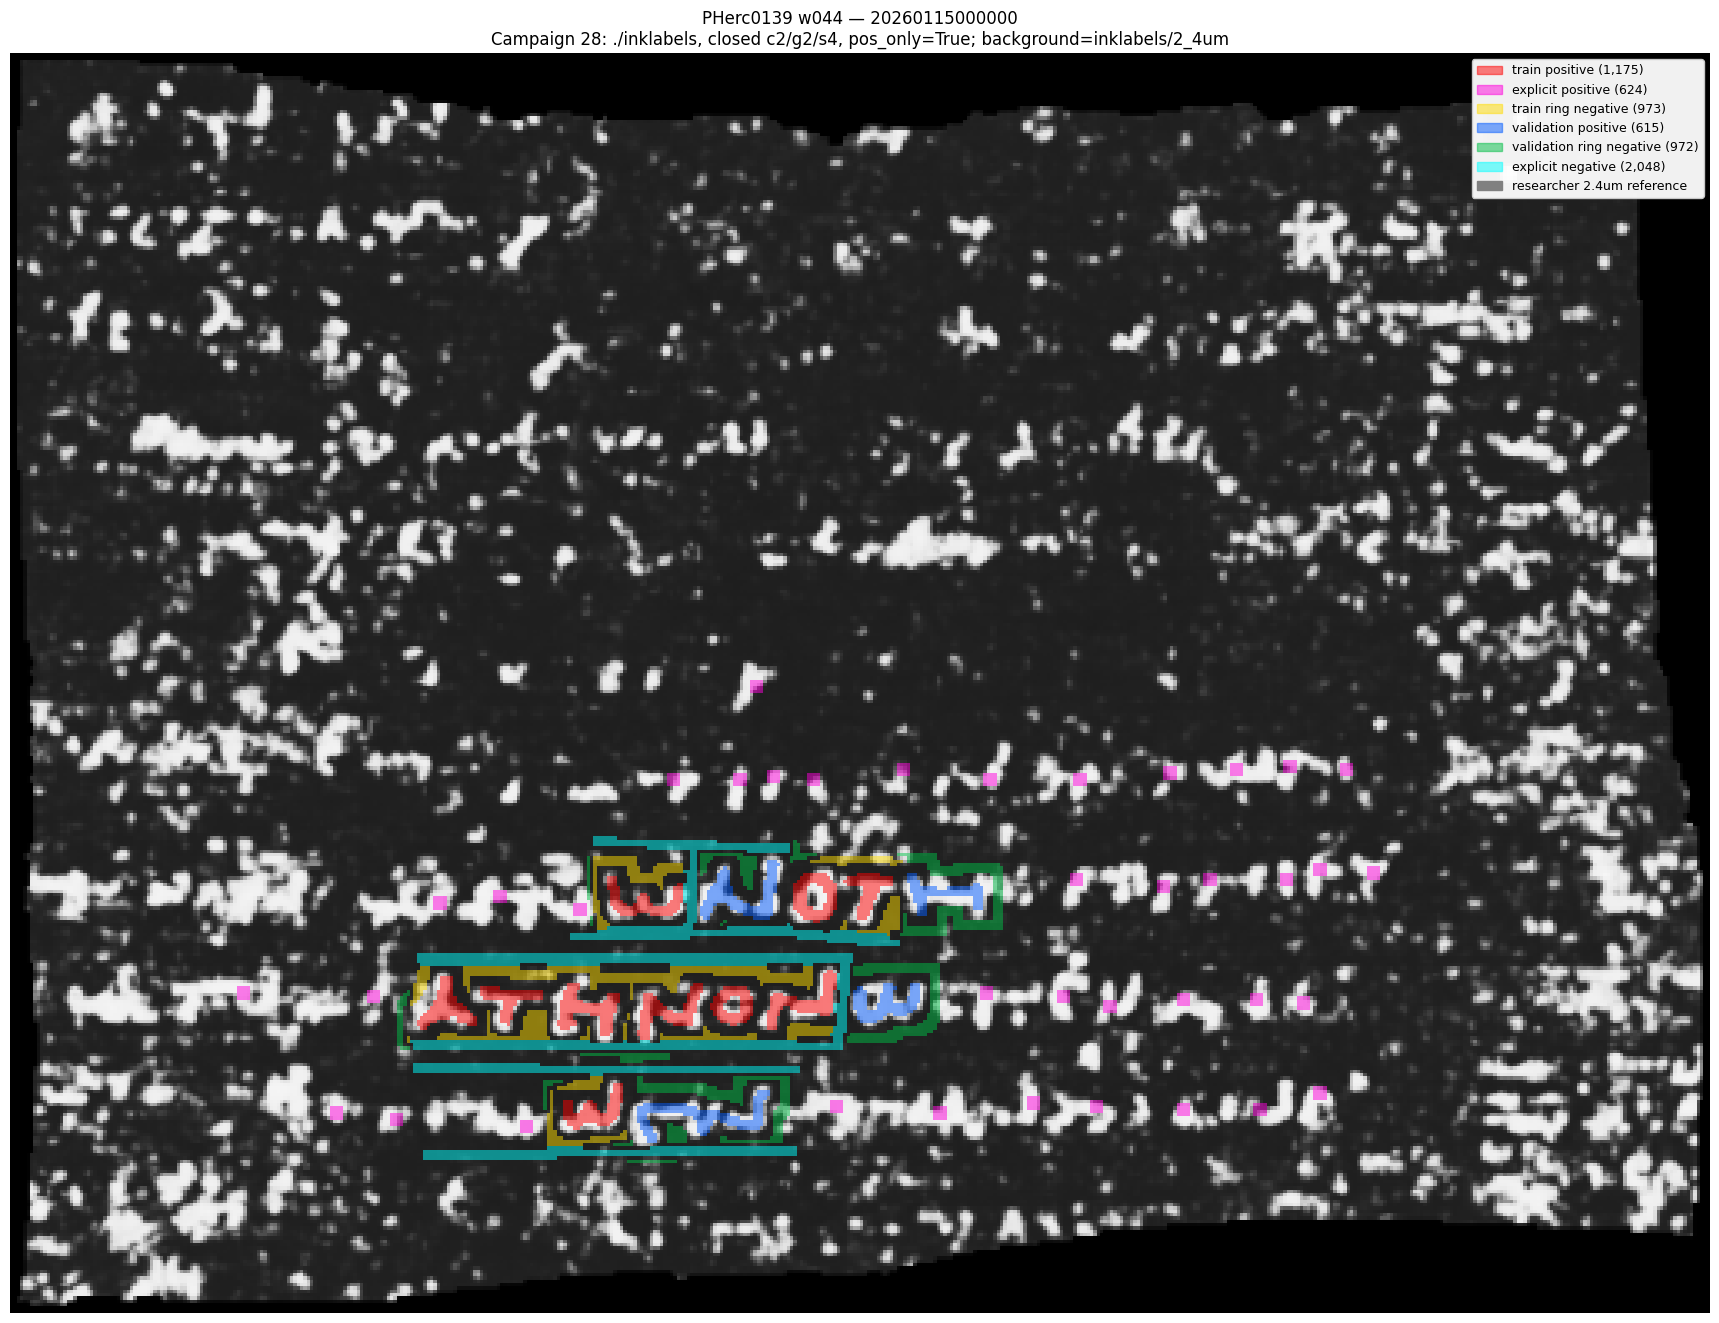

{'train_positive': 1175,
 'explicit_positive': 624,
 'train_negative': 973,
 'valid_positive': 615,
 'valid_negative': 972,
 'explicit_negative': 2048}

In [3]:
render_scroll(20260115000000, SCROLL_NAMES[20260115000000])

[split] scroll 20260317000000: manual mask=./train_masks/20260317000000.png train_pixels=8.0% explicit_negative_pixels=792,832 explicit_positive_pixels=185,900
[split] scroll 20260317000000: axis=y train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=5427
[ring_negatives] source='closed' tile_radius=4  ink_tiles=3803  ring_tiles=5377  ratio=1.41
[manual-split] scroll 20260317000000: unit=16px train_ring=1641728px valid_ring=708352px
[context-replace] scroll 20260317000000: 2322 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20260317000000_campaign28_split.png
unique targets {'train_positive': 1327, 'explicit_positive': 708, 'train_negative': 1209, 'valid_positive': 680, 'valid_negative': 1135, 'explicit_negative': 2528}
train occurrences {'windows': 12583, 'positive_occurrences': 21232, 'negative_occurrences': 19344, 'explicit_positive_occurrences': 11328, 'explicit_negative_occurrences': 40448}
valid occurrences {'windows'

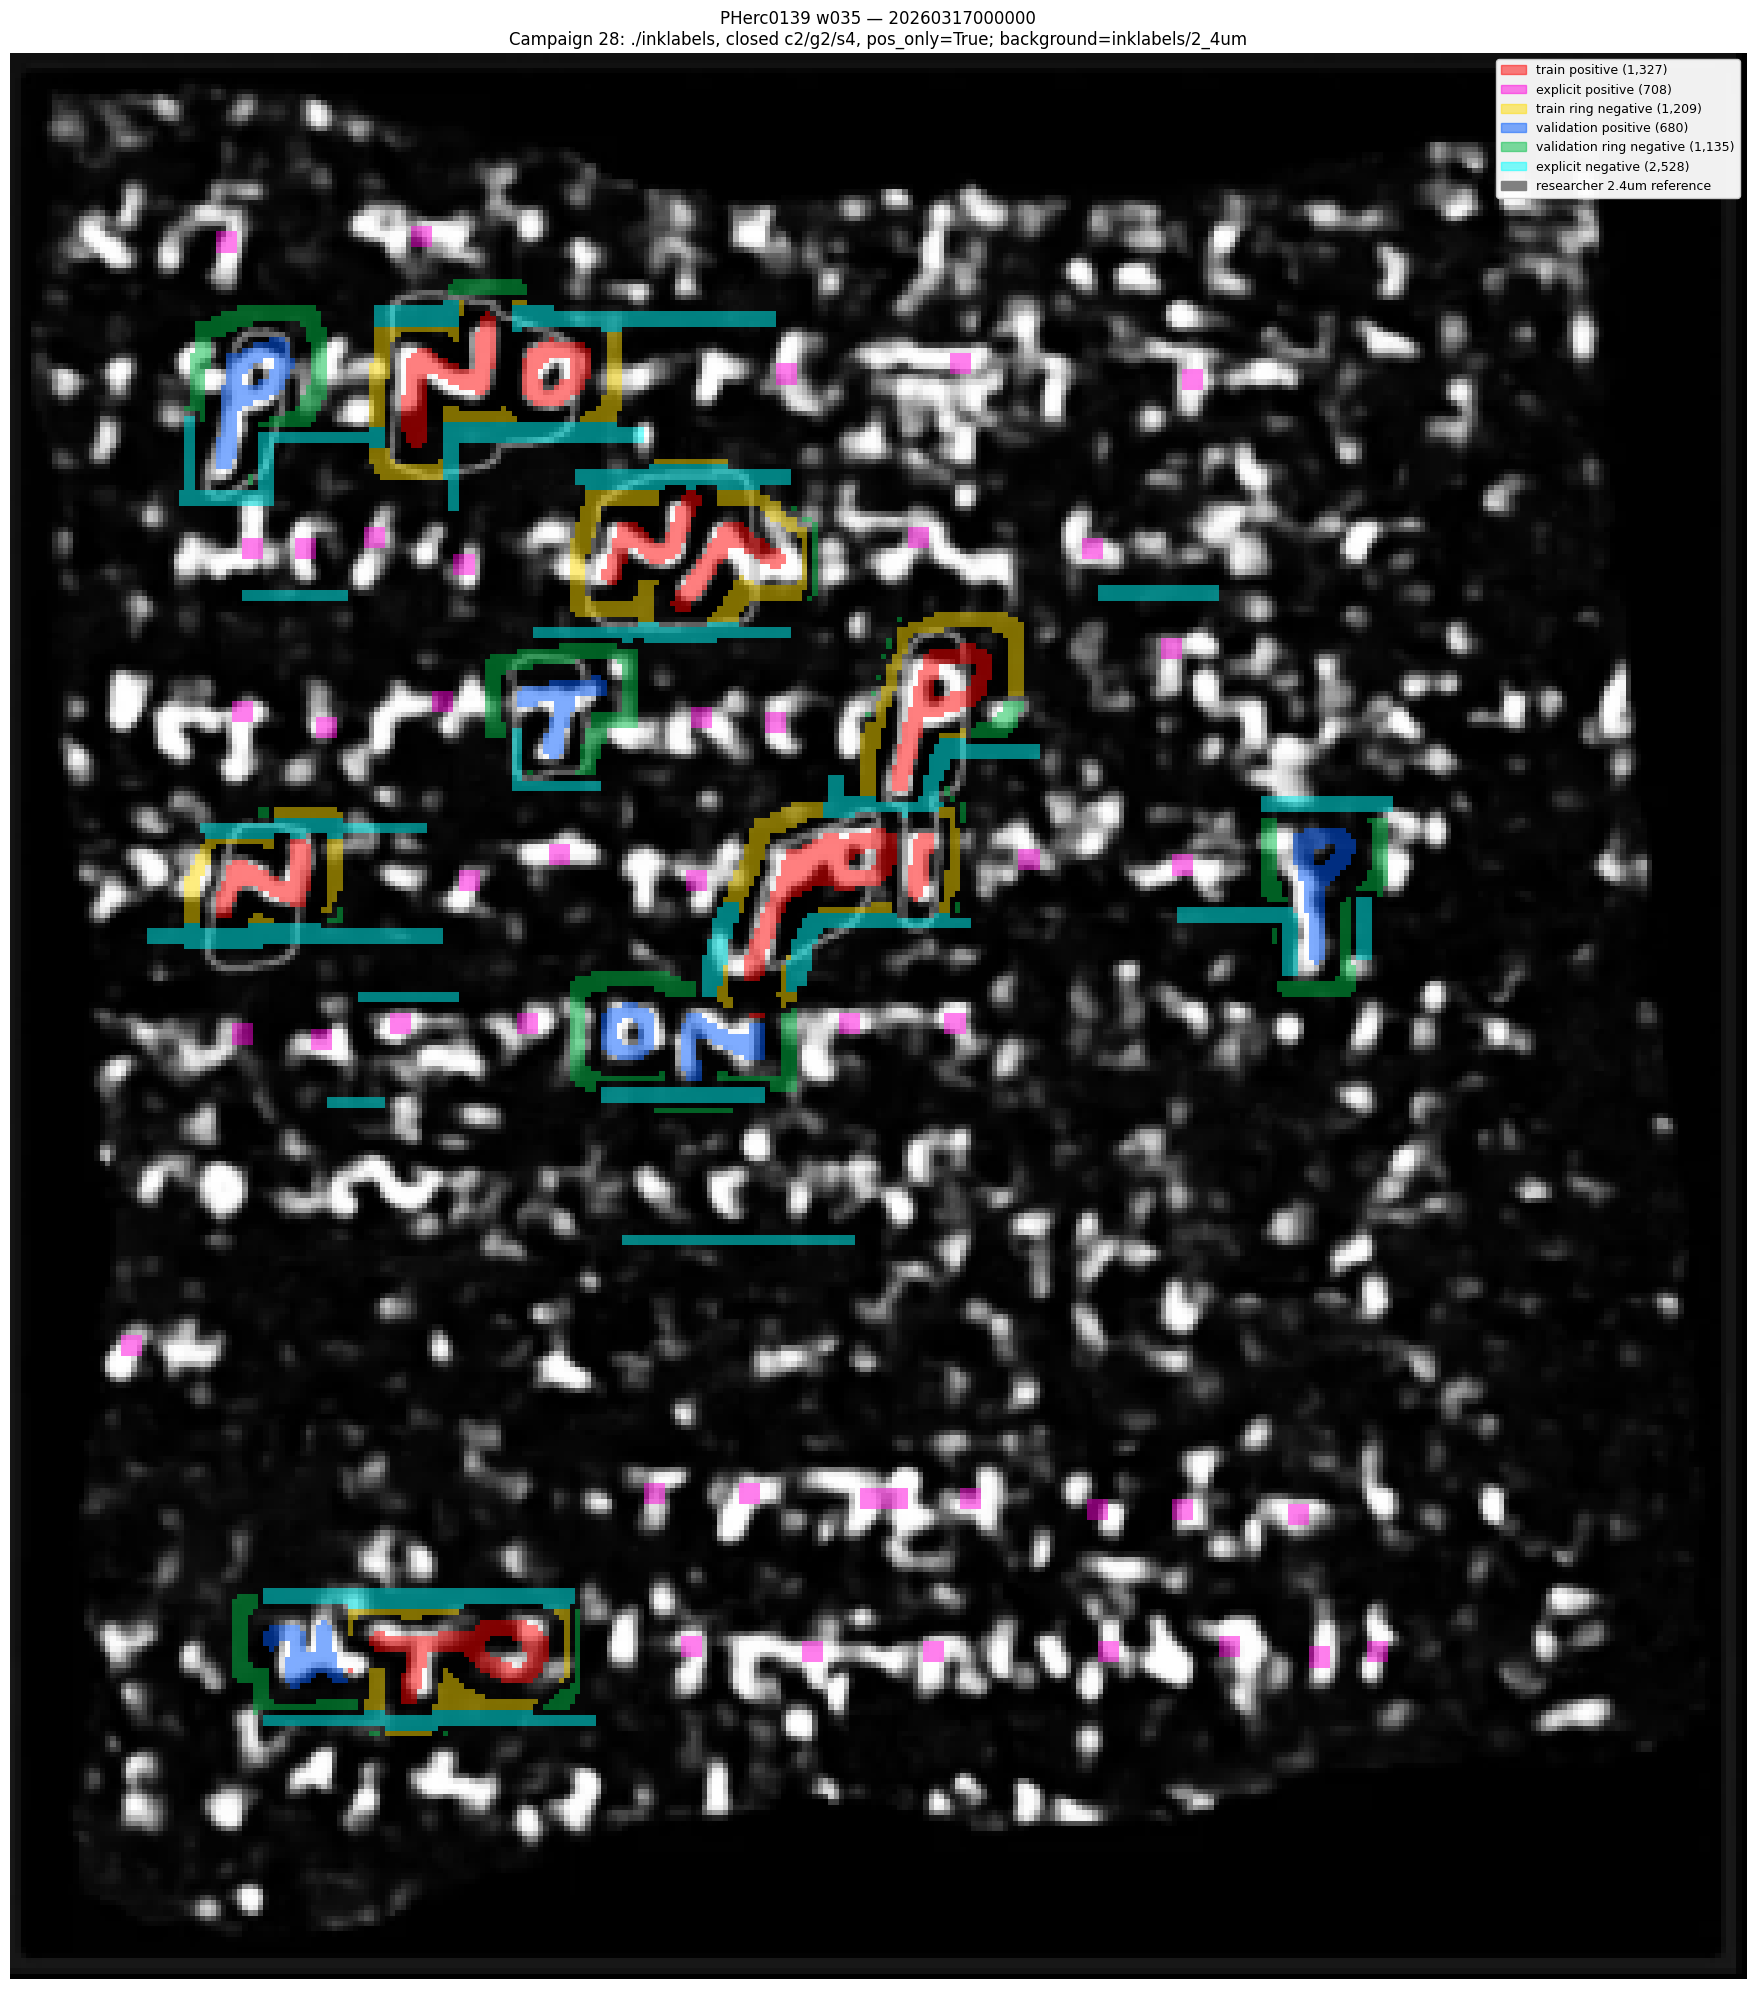

{'train_positive': 1327,
 'explicit_positive': 708,
 'train_negative': 1209,
 'valid_positive': 680,
 'valid_negative': 1135,
 'explicit_negative': 2528}

In [4]:
render_scroll(20260317000000, SCROLL_NAMES[20260317000000])

[explicit-negative] scroll 20250223000000: overriding 318 ink-label pixels
[split] scroll 20250223000000: manual mask=./train_masks/20250223000000.png train_pixels=2.6% explicit_negative_pixels=649,472 explicit_positive_pixels=178,451
[split] scroll 20250223000000: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=6340
[ring_negatives] source='closed' tile_radius=4  ink_tiles=4085  ring_tiles=6660  ratio=1.63
[manual-split] scroll 20250223000000: unit=16px train_ring=1180928px valid_ring=1568512px
[context-replace] scroll 20250223000000: 2315 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20250223000000_campaign28_split.png
unique targets {'train_positive': 730, 'explicit_positive': 676, 'train_negative': 1206, 'valid_positive': 1505, 'valid_negative': 2886, 'explicit_negative': 2036}
train occurrences {'windows': 9895, 'positive_occurrences': 11680, 'negative_occurrences': 19296, 'explicit_positive_occurrences': 

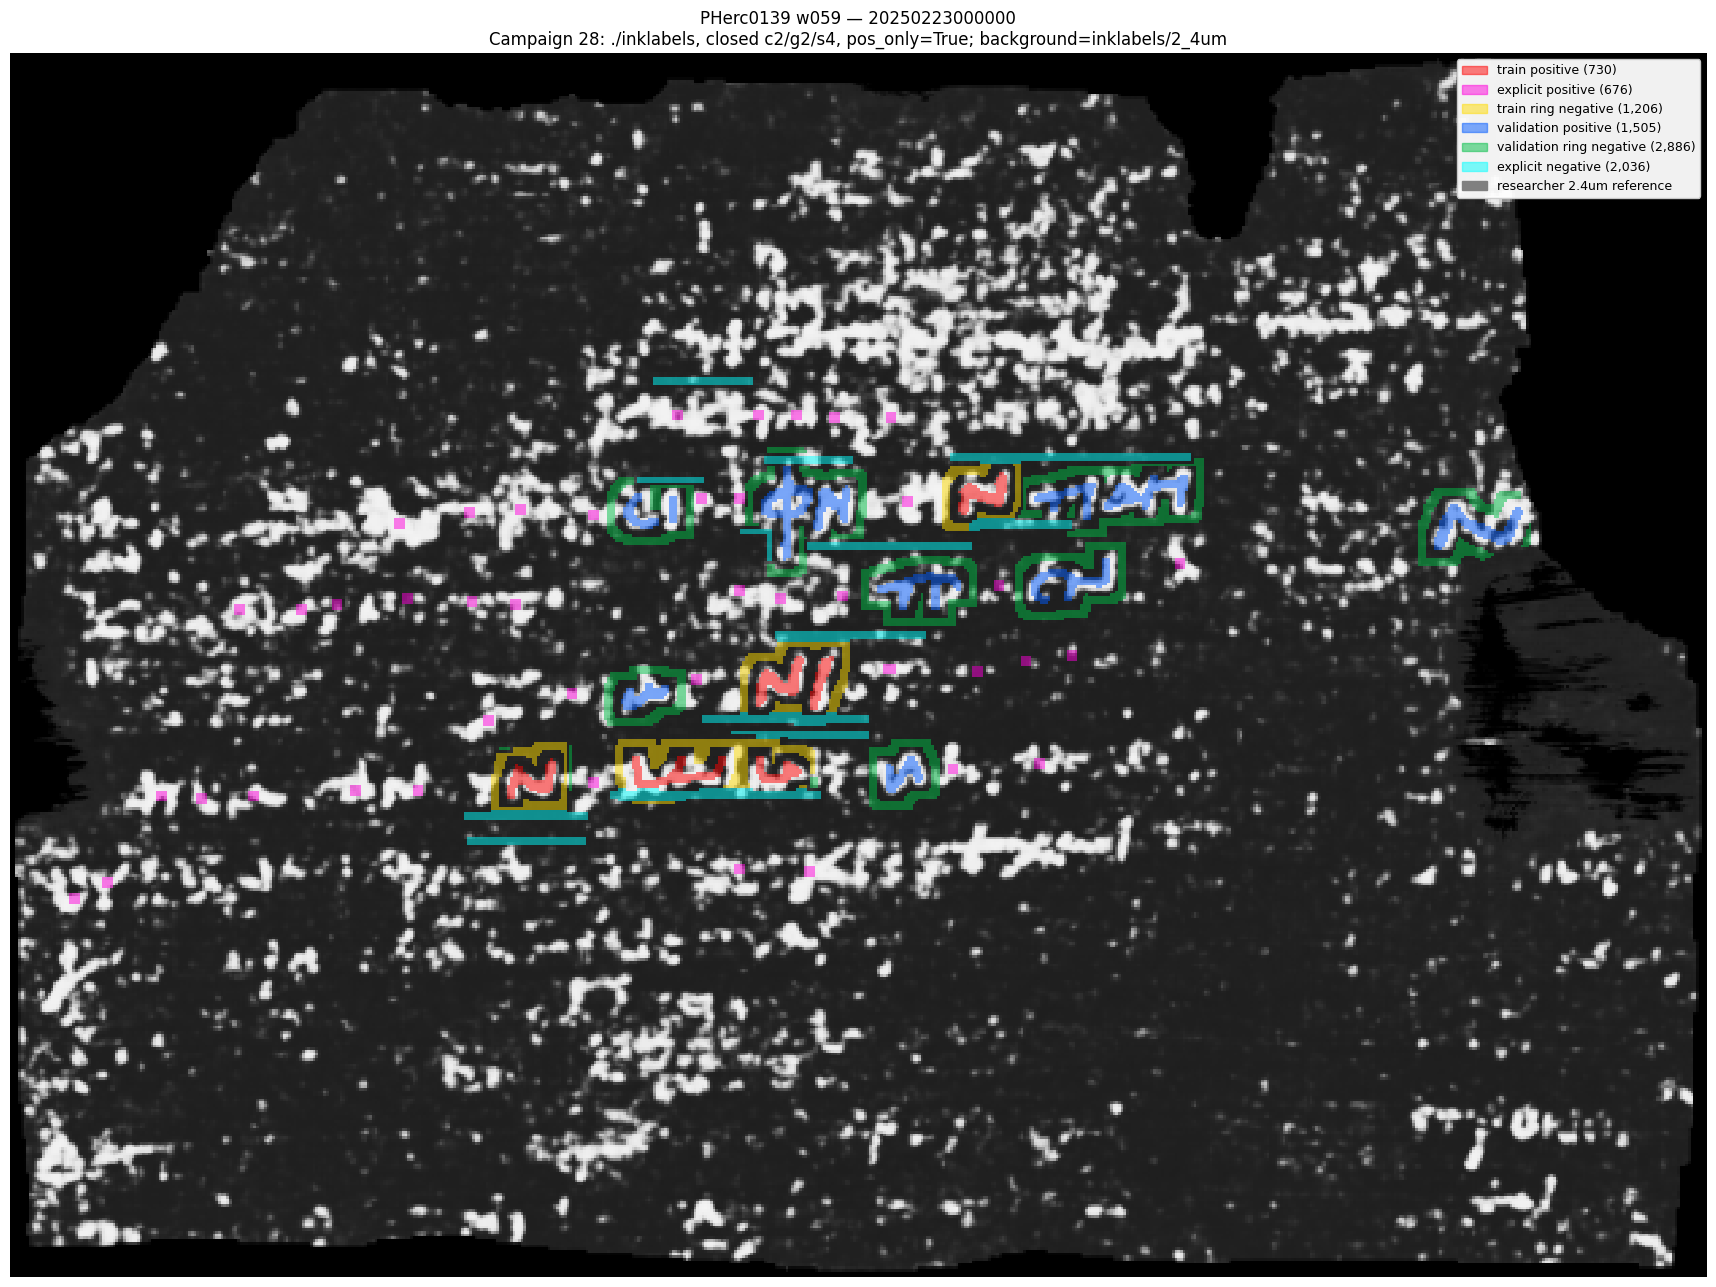

{'train_positive': 730,
 'explicit_positive': 676,
 'train_negative': 1206,
 'valid_positive': 1505,
 'valid_negative': 2886,
 'explicit_negative': 2036}

In [5]:
render_scroll(20250223000000, SCROLL_NAMES[20250223000000])

[split] scroll 20251111010954: manual mask=./train_masks/20251111010954.png train_pixels=3.9% explicit_negative_pixels=975,360 explicit_positive_pixels=0
[split] scroll 20251111010954: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=6880
[ring_negatives] source='closed' tile_radius=4  ink_tiles=3186  ring_tiles=7825  ratio=2.46
[manual-split] scroll 20251111010954: unit=16px train_ring=2479616px valid_ring=339200px
[context-replace] scroll 20251111010954: 9884 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20251111010954_campaign28_split.png
unique targets {'train_positive': 2047, 'explicit_positive': 0, 'train_negative': 4379, 'valid_positive': 265, 'valid_negative': 651, 'explicit_negative': 3087}
train occurrences {'windows': 18947, 'positive_occurrences': 32752, 'negative_occurrences': 70064, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 49392}
valid occurrences {'windows': 1990, 'posi

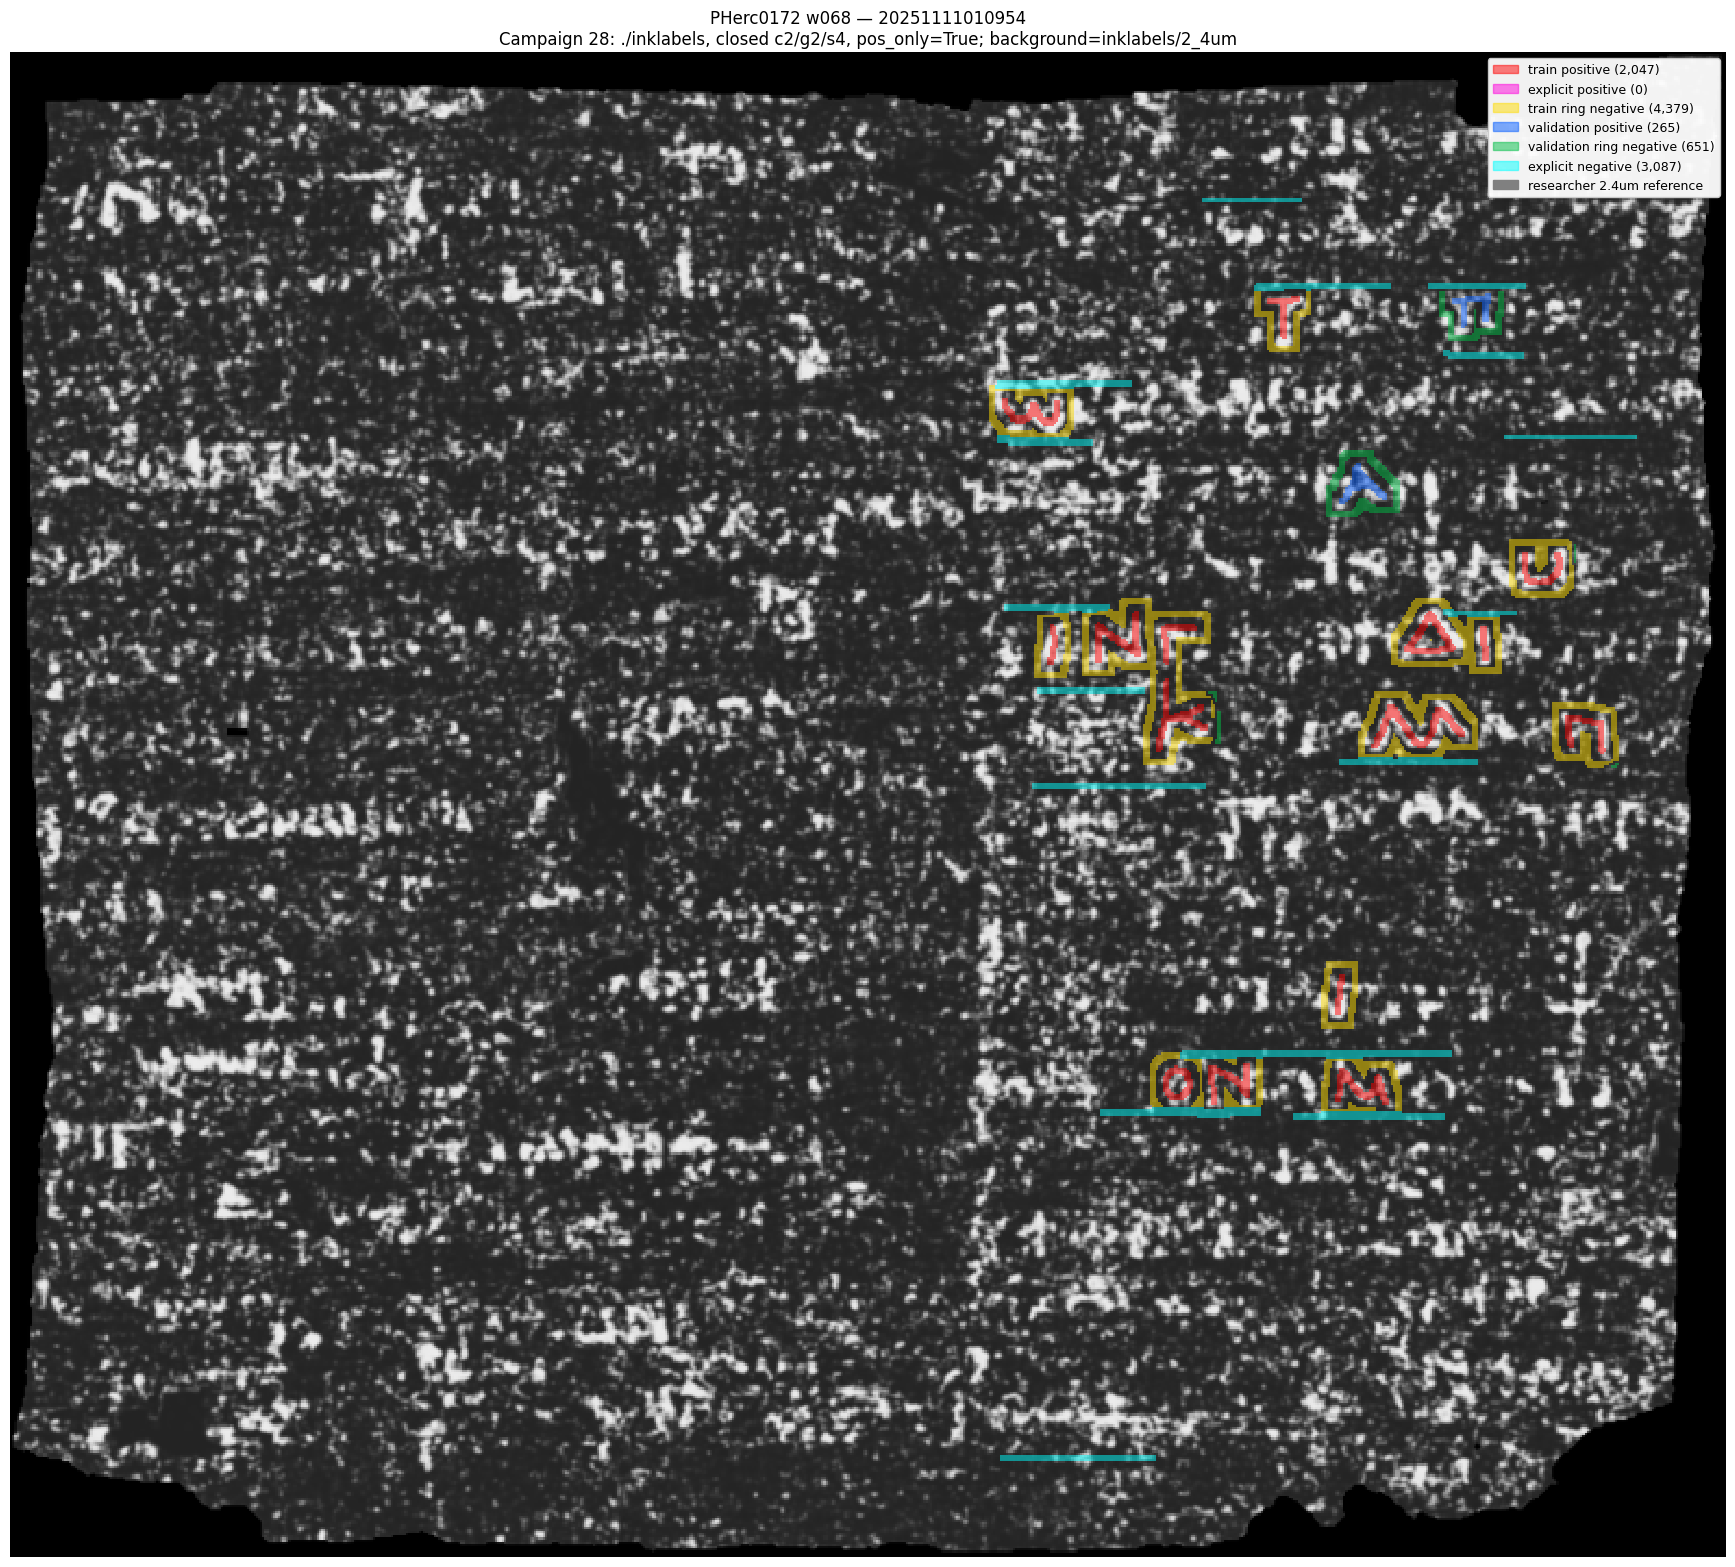

{'train_positive': 2047,
 'explicit_positive': 0,
 'train_negative': 4379,
 'valid_positive': 265,
 'valid_negative': 651,
 'explicit_negative': 3087}

In [6]:
render_scroll(20251111010954, SCROLL_NAMES[20251111010954])

[split] scroll 20251112000002: manual mask=./train_masks/20251112000002.png train_pixels=12.0% explicit_negative_pixels=1,833,216 explicit_positive_pixels=0
[split] scroll 20251112000002: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=16730
[ring_negatives] source='closed' tile_radius=4  ink_tiles=7806  ring_tiles=17507  ratio=2.24
[manual-split] scroll 20251112000002: unit=16px train_ring=4593152px valid_ring=1886976px
[context-replace] scroll 20251112000002: 17799 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20251112000002_campaign28_split.png
unique targets {'train_positive': 4194, 'explicit_positive': 0, 'train_negative': 8100, 'valid_positive': 1461, 'valid_negative': 3881, 'explicit_negative': 5554}
train occurrences {'windows': 36228, 'positive_occurrences': 67104, 'negative_occurrences': 129600, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 88864}
valid occurrences {'windows': 1

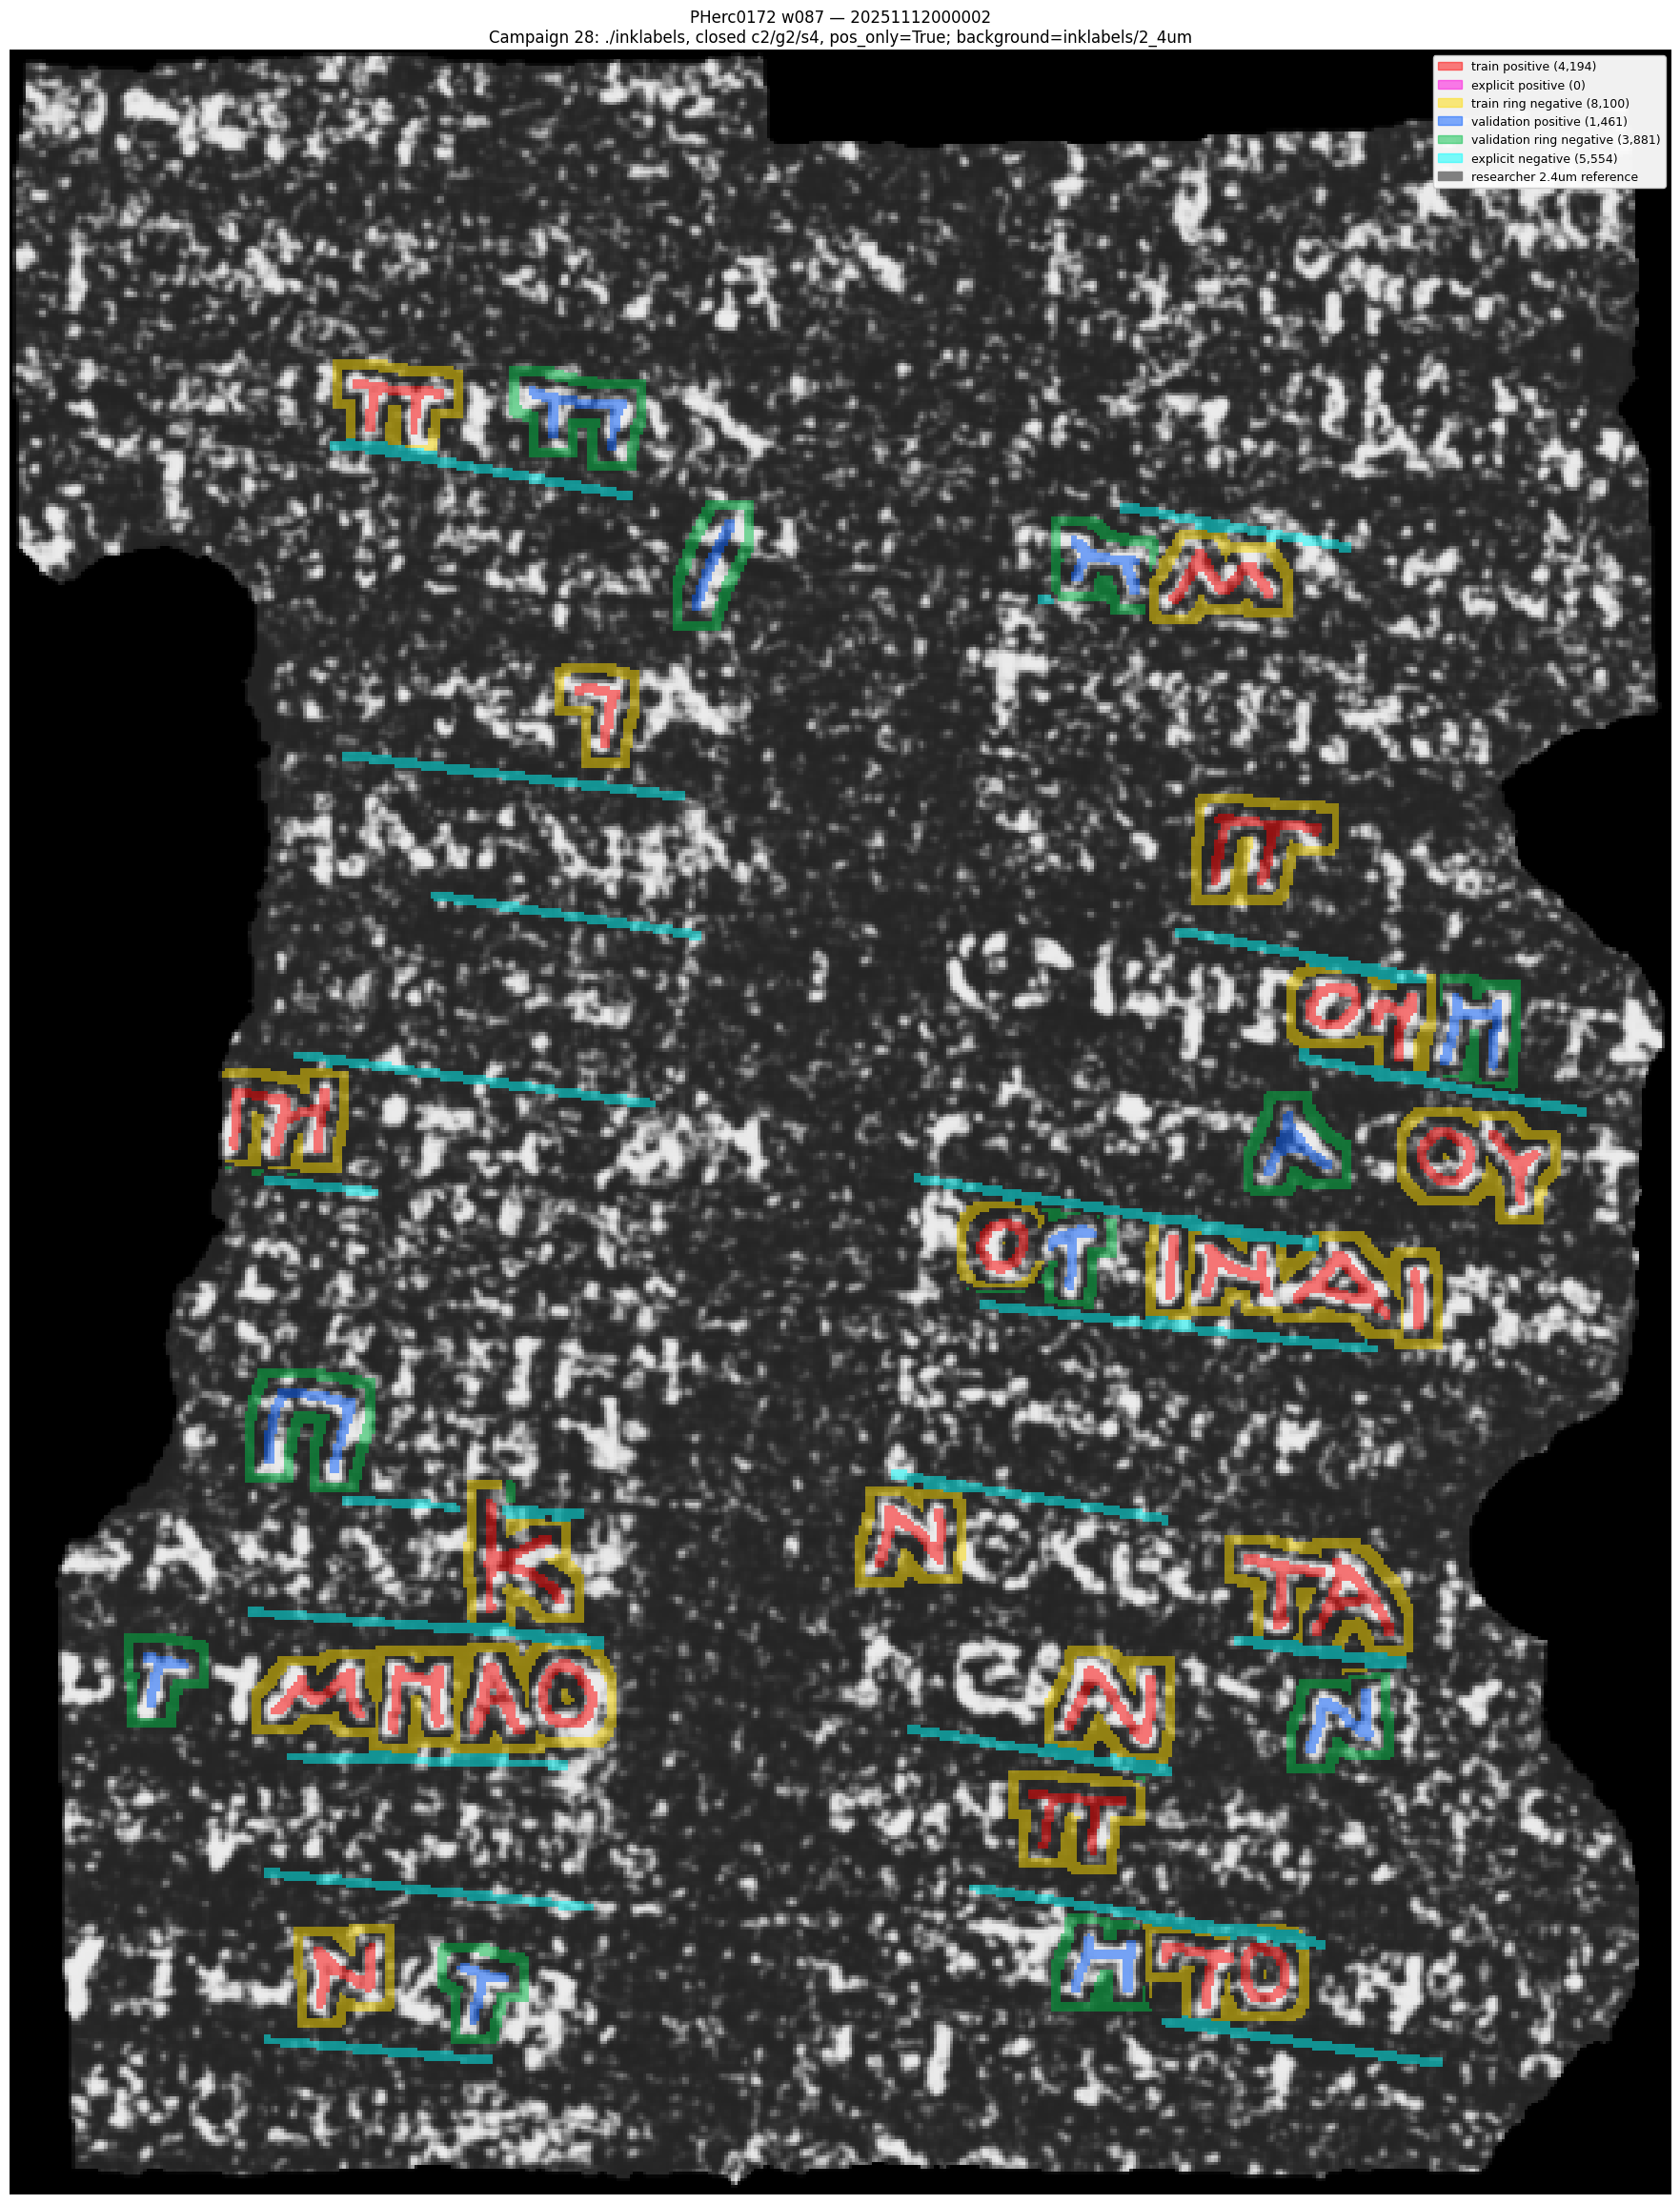

{'train_positive': 4194,
 'explicit_positive': 0,
 'train_negative': 8100,
 'valid_positive': 1461,
 'valid_negative': 3881,
 'explicit_negative': 5554}

In [7]:
render_scroll(20251112000002, SCROLL_NAMES[20251112000002])

[split] scroll 20240304141531: manual mask=./train_masks/20240304141531.png train_pixels=18.4% explicit_negative_pixels=702,464 explicit_positive_pixels=0
[split] scroll 20240304141531: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=36378
[ring_negatives] source='closed' tile_radius=4  ink_tiles=17607  ring_tiles=36472  ratio=2.07
[manual-split] scroll 20240304141531: unit=16px train_ring=6134528px valid_ring=7709696px
[context-replace] scroll 20240304141531: 7852 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20240304141531_campaign28_split.png
unique targets {'train_positive': 5901, 'explicit_positive': 0, 'train_negative': 11319, 'valid_positive': 7226, 'valid_negative': 14614, 'explicit_negative': 2140}
train occurrences {'windows': 39162, 'positive_occurrences': 94416, 'negative_occurrences': 181104, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 34240}
valid occurrences {'windows': 4

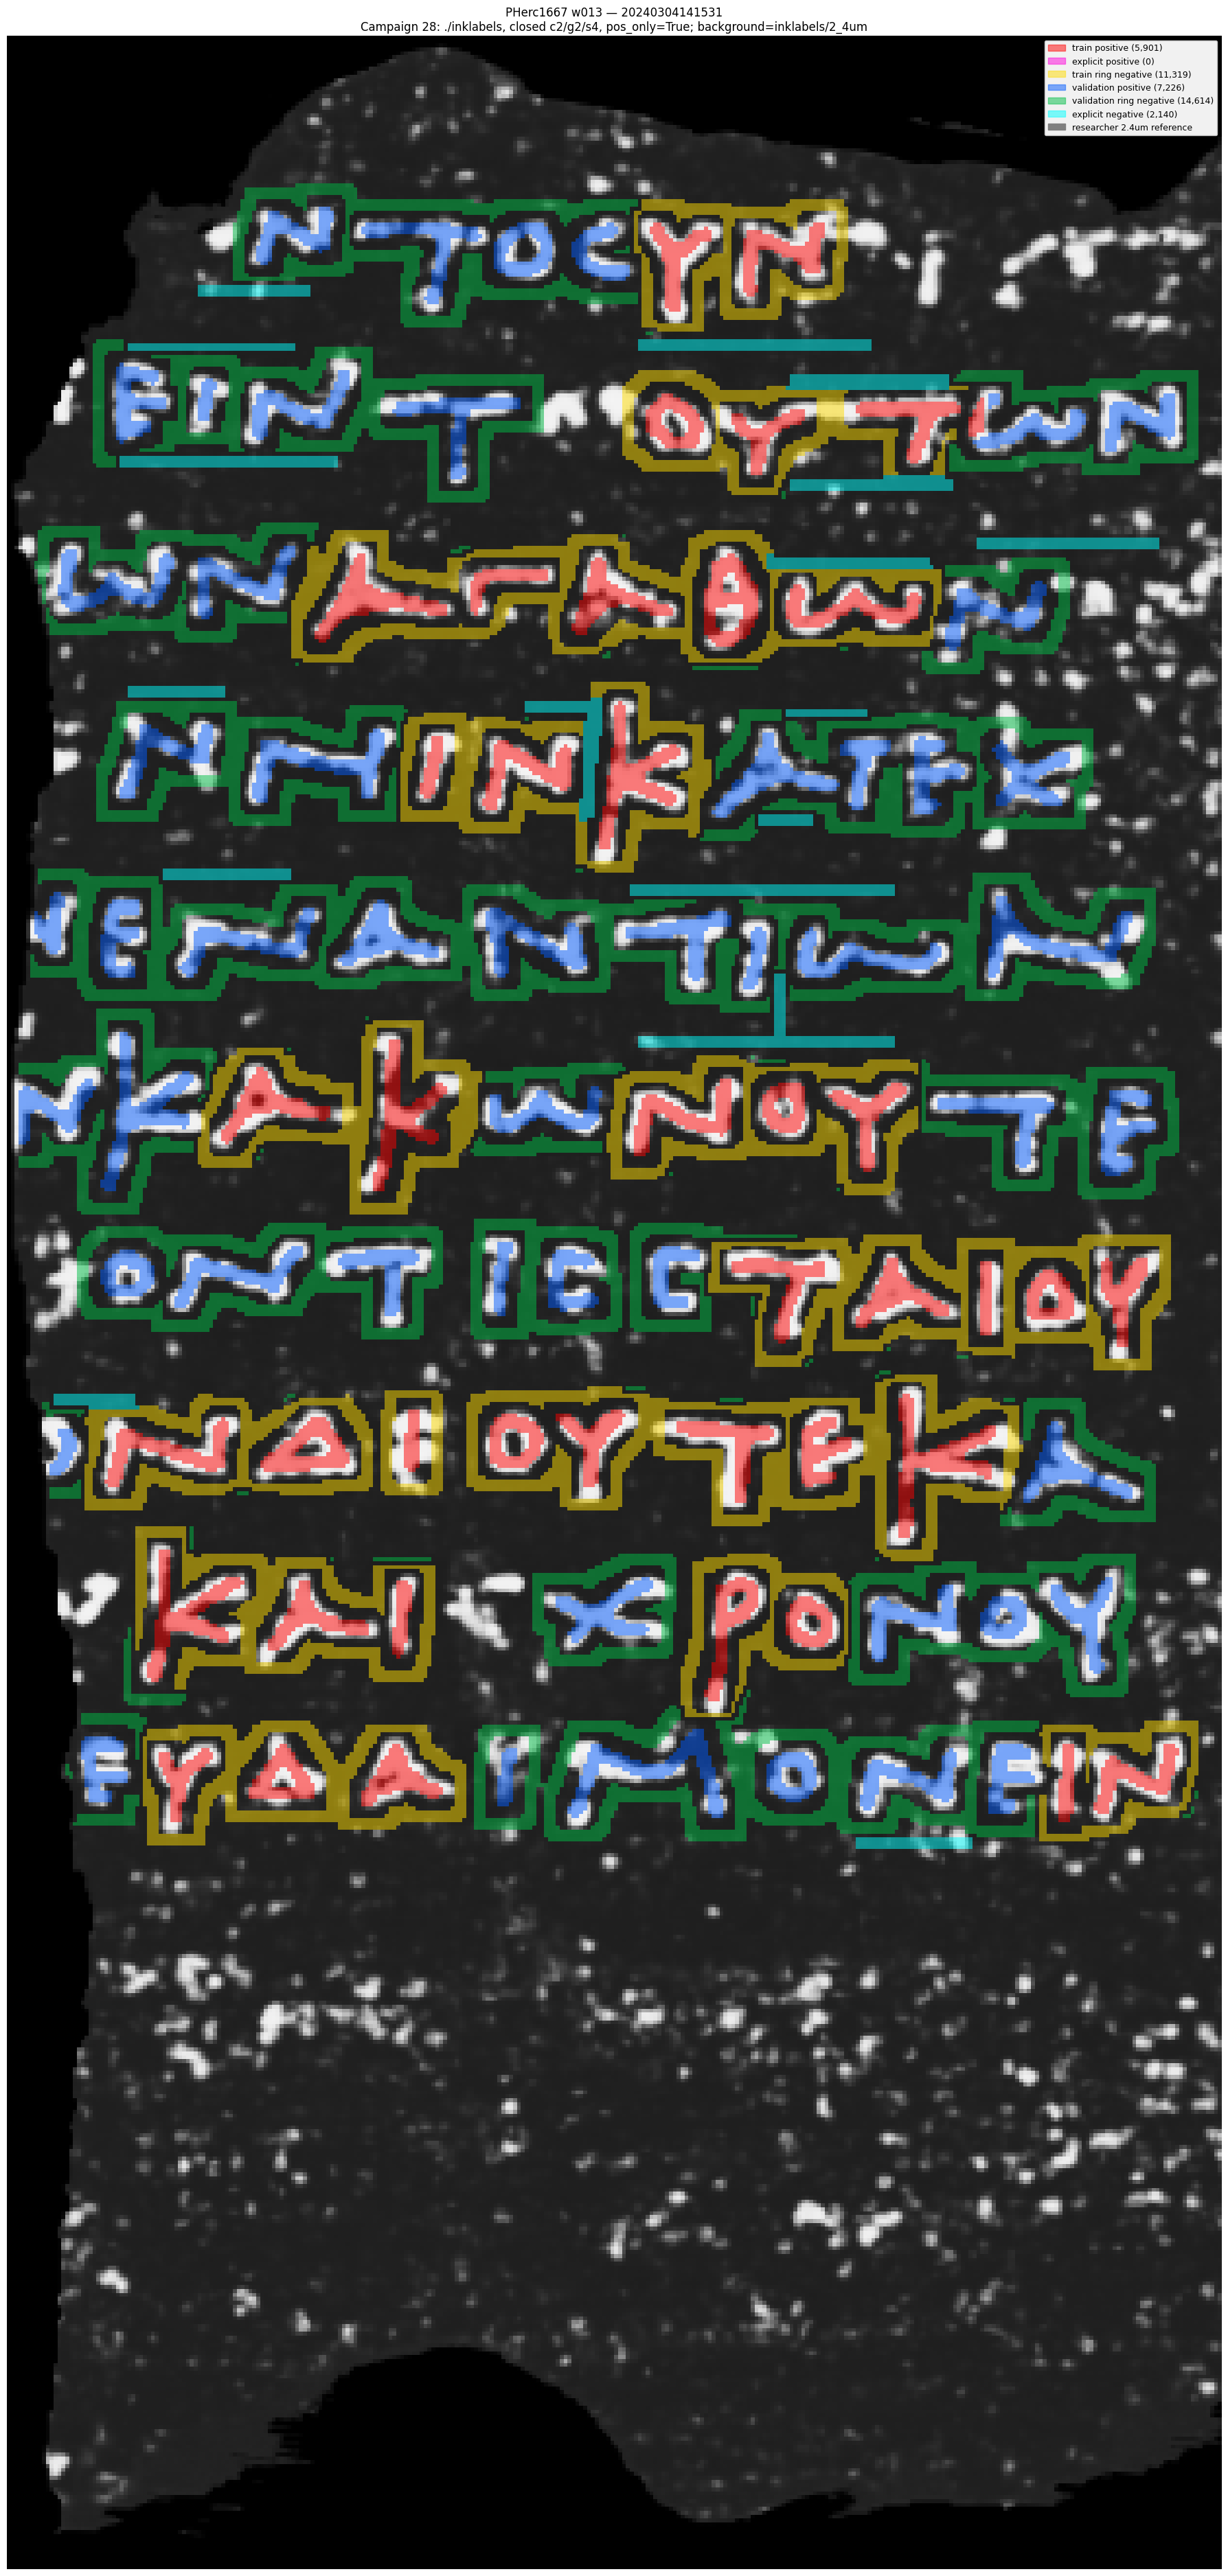

{'train_positive': 5901,
 'explicit_positive': 0,
 'train_negative': 11319,
 'valid_positive': 7226,
 'valid_negative': 14614,
 'explicit_negative': 2140}

In [8]:
render_scroll(20240304141531, SCROLL_NAMES[20240304141531])

[explicit-negative] scroll 20240304144031: overriding 93 ink-label pixels
[split] scroll 20240304144031: manual mask=./train_masks/20240304144031.png train_pixels=4.3% explicit_negative_pixels=1,499,393 explicit_positive_pixels=533,195
[split] scroll 20240304144031: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=21327
[ring_negatives] source='closed' tile_radius=4  ink_tiles=13015  ring_tiles=23369  ratio=1.80
[manual-split] scroll 20240304144031: unit=16px train_ring=5948672px valid_ring=3364608px
[context-replace] scroll 20240304144031: 17618 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20240304144031_campaign28_split.png
unique targets {'train_positive': 4393, 'explicit_positive': 2016, 'train_negative': 9796, 'valid_positive': 2754, 'valid_negative': 6867, 'explicit_negative': 4542}
train occurrences {'windows': 44125, 'positive_occurrences': 70288, 'negative_occurrences': 156736, 'explicit_positive_occur

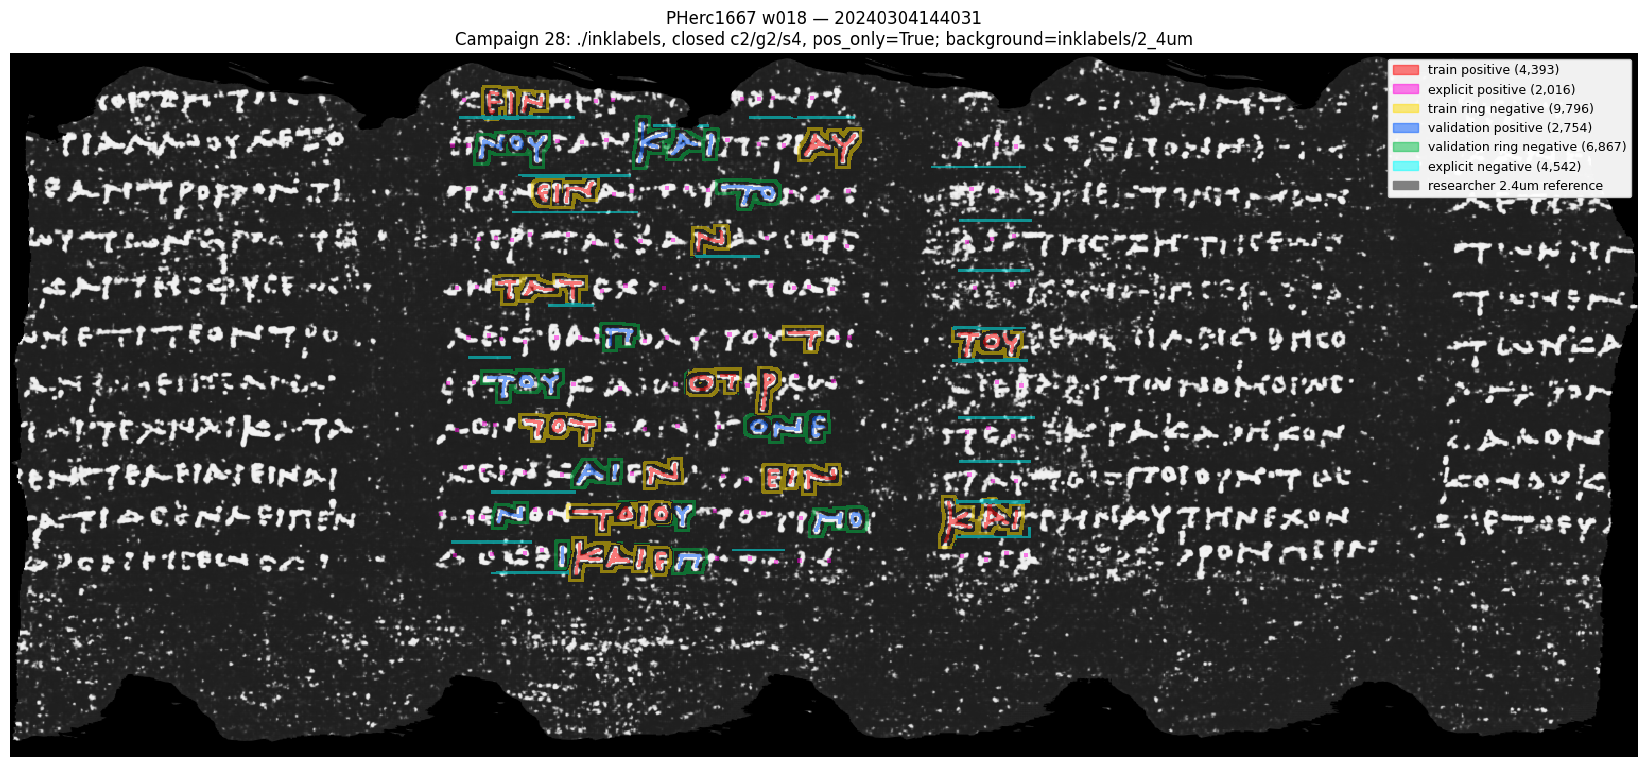

{'train_positive': 4393,
 'explicit_positive': 2016,
 'train_negative': 9796,
 'valid_positive': 2754,
 'valid_negative': 6867,
 'explicit_negative': 4542}

In [17]:
render_scroll(20240304144031, SCROLL_NAMES[20240304144031])

[split] scroll 20250919125754: manual mask=./train_masks/20250919125754.png train_pixels=5.8% explicit_negative_pixels=488,960 explicit_positive_pixels=0
[split] scroll 20250919125754: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=4978
[ring_negatives] source='closed' tile_radius=4  ink_tiles=2389  ring_tiles=4091  ratio=1.71
[manual-split] scroll 20250919125754: unit=16px train_ring=1127424px valid_ring=531456px
[context-replace] scroll 20250919125754: 2114 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20250919125754_campaign28_split.png
unique targets {'train_positive': 1225, 'explicit_positive': 0, 'train_negative': 1258, 'valid_positive': 511, 'valid_negative': 941, 'explicit_negative': 1675}
train occurrences {'windows': 8057, 'positive_occurrences': 19600, 'negative_occurrences': 20128, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 26800}
valid occurrences {'windows': 3284, 'posit

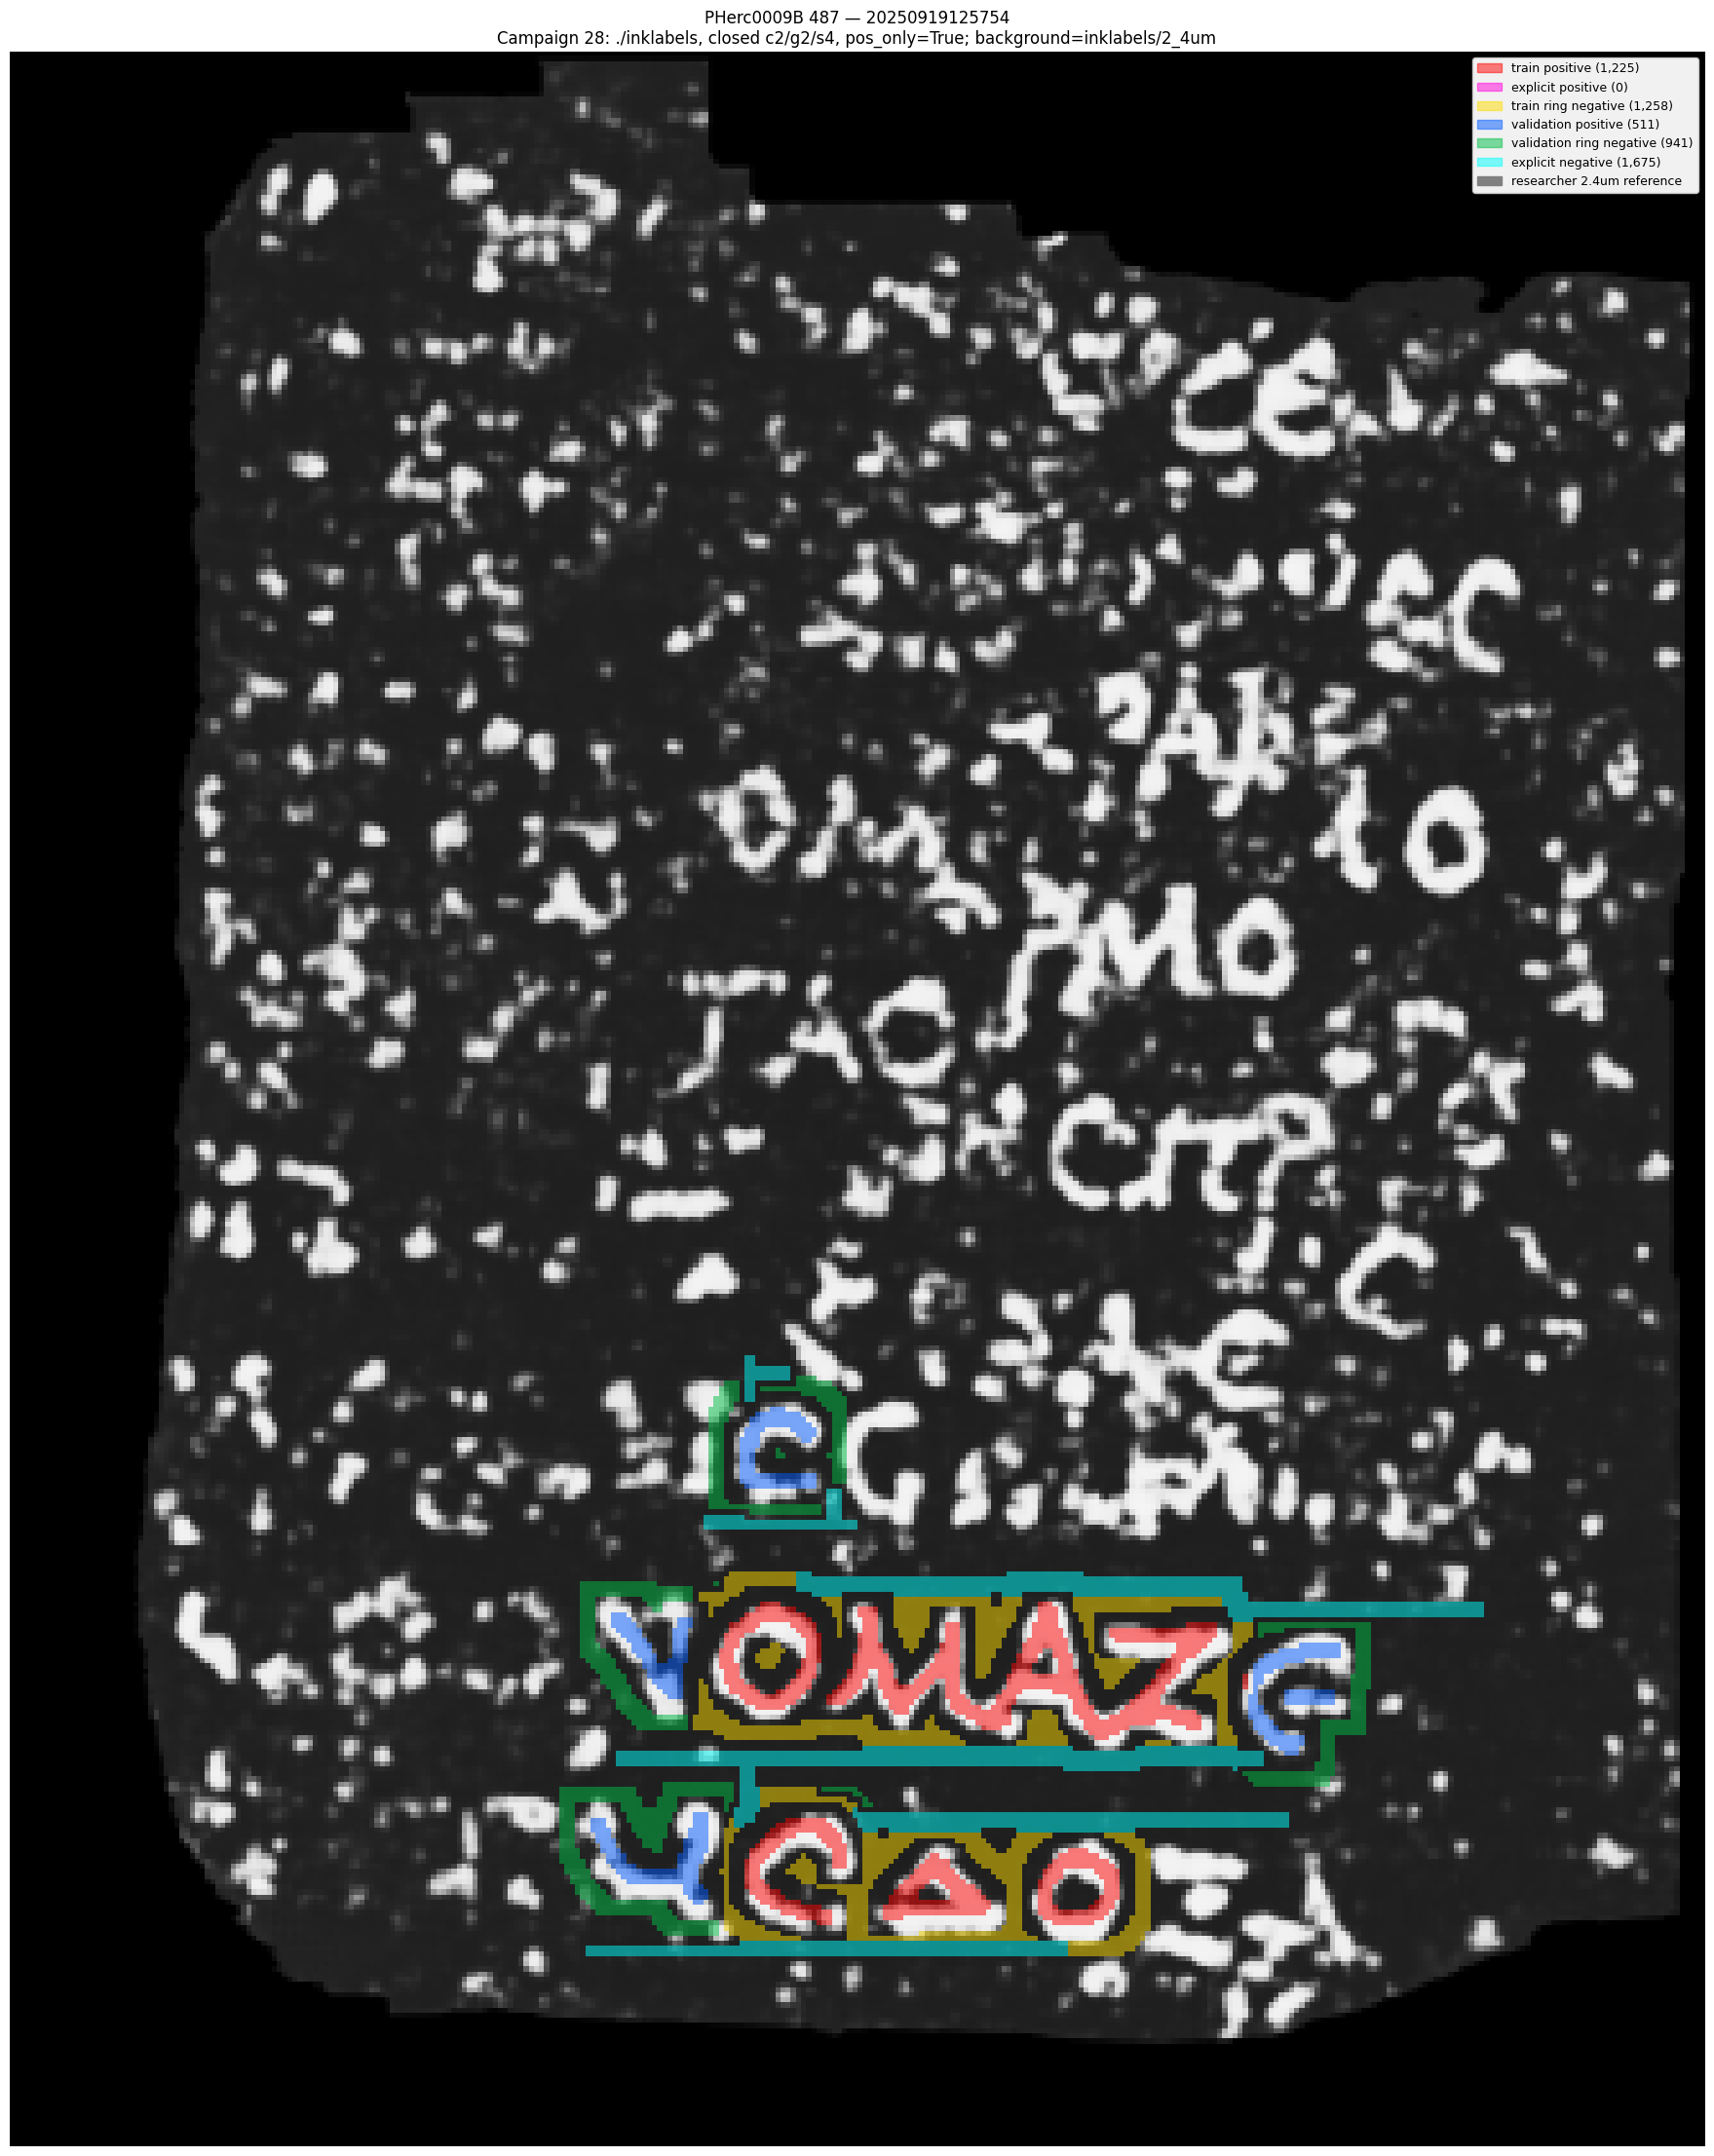

{'train_positive': 1225,
 'explicit_positive': 0,
 'train_negative': 1258,
 'valid_positive': 511,
 'valid_negative': 941,
 'explicit_negative': 1675}

In [10]:
render_scroll(20250919125754, SCROLL_NAMES[20250919125754])

[split] scroll 20231210121321: manual mask=./train_masks/20231210121321.png train_pixels=10.9% explicit_negative_pixels=1,645,056 explicit_positive_pixels=0
[split] scroll 20231210121321: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=29541
[ring_negatives] source='closed' tile_radius=4  ink_tiles=14315  ring_tiles=29417  ratio=2.05
[manual-split] scroll 20231210121321: unit=16px train_ring=6801664px valid_ring=4393728px
[context-replace] scroll 20231210121321: 22661 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20231210121321_campaign28_split.png
unique targets {'train_positive': 6278, 'explicit_positive': 0, 'train_negative': 12533, 'valid_positive': 4361, 'valid_negative': 8266, 'explicit_negative': 4921}
train occurrences {'windows': 47891, 'positive_occurrences': 100448, 'negative_occurrences': 200528, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 78736}
valid occurrences {'windows'

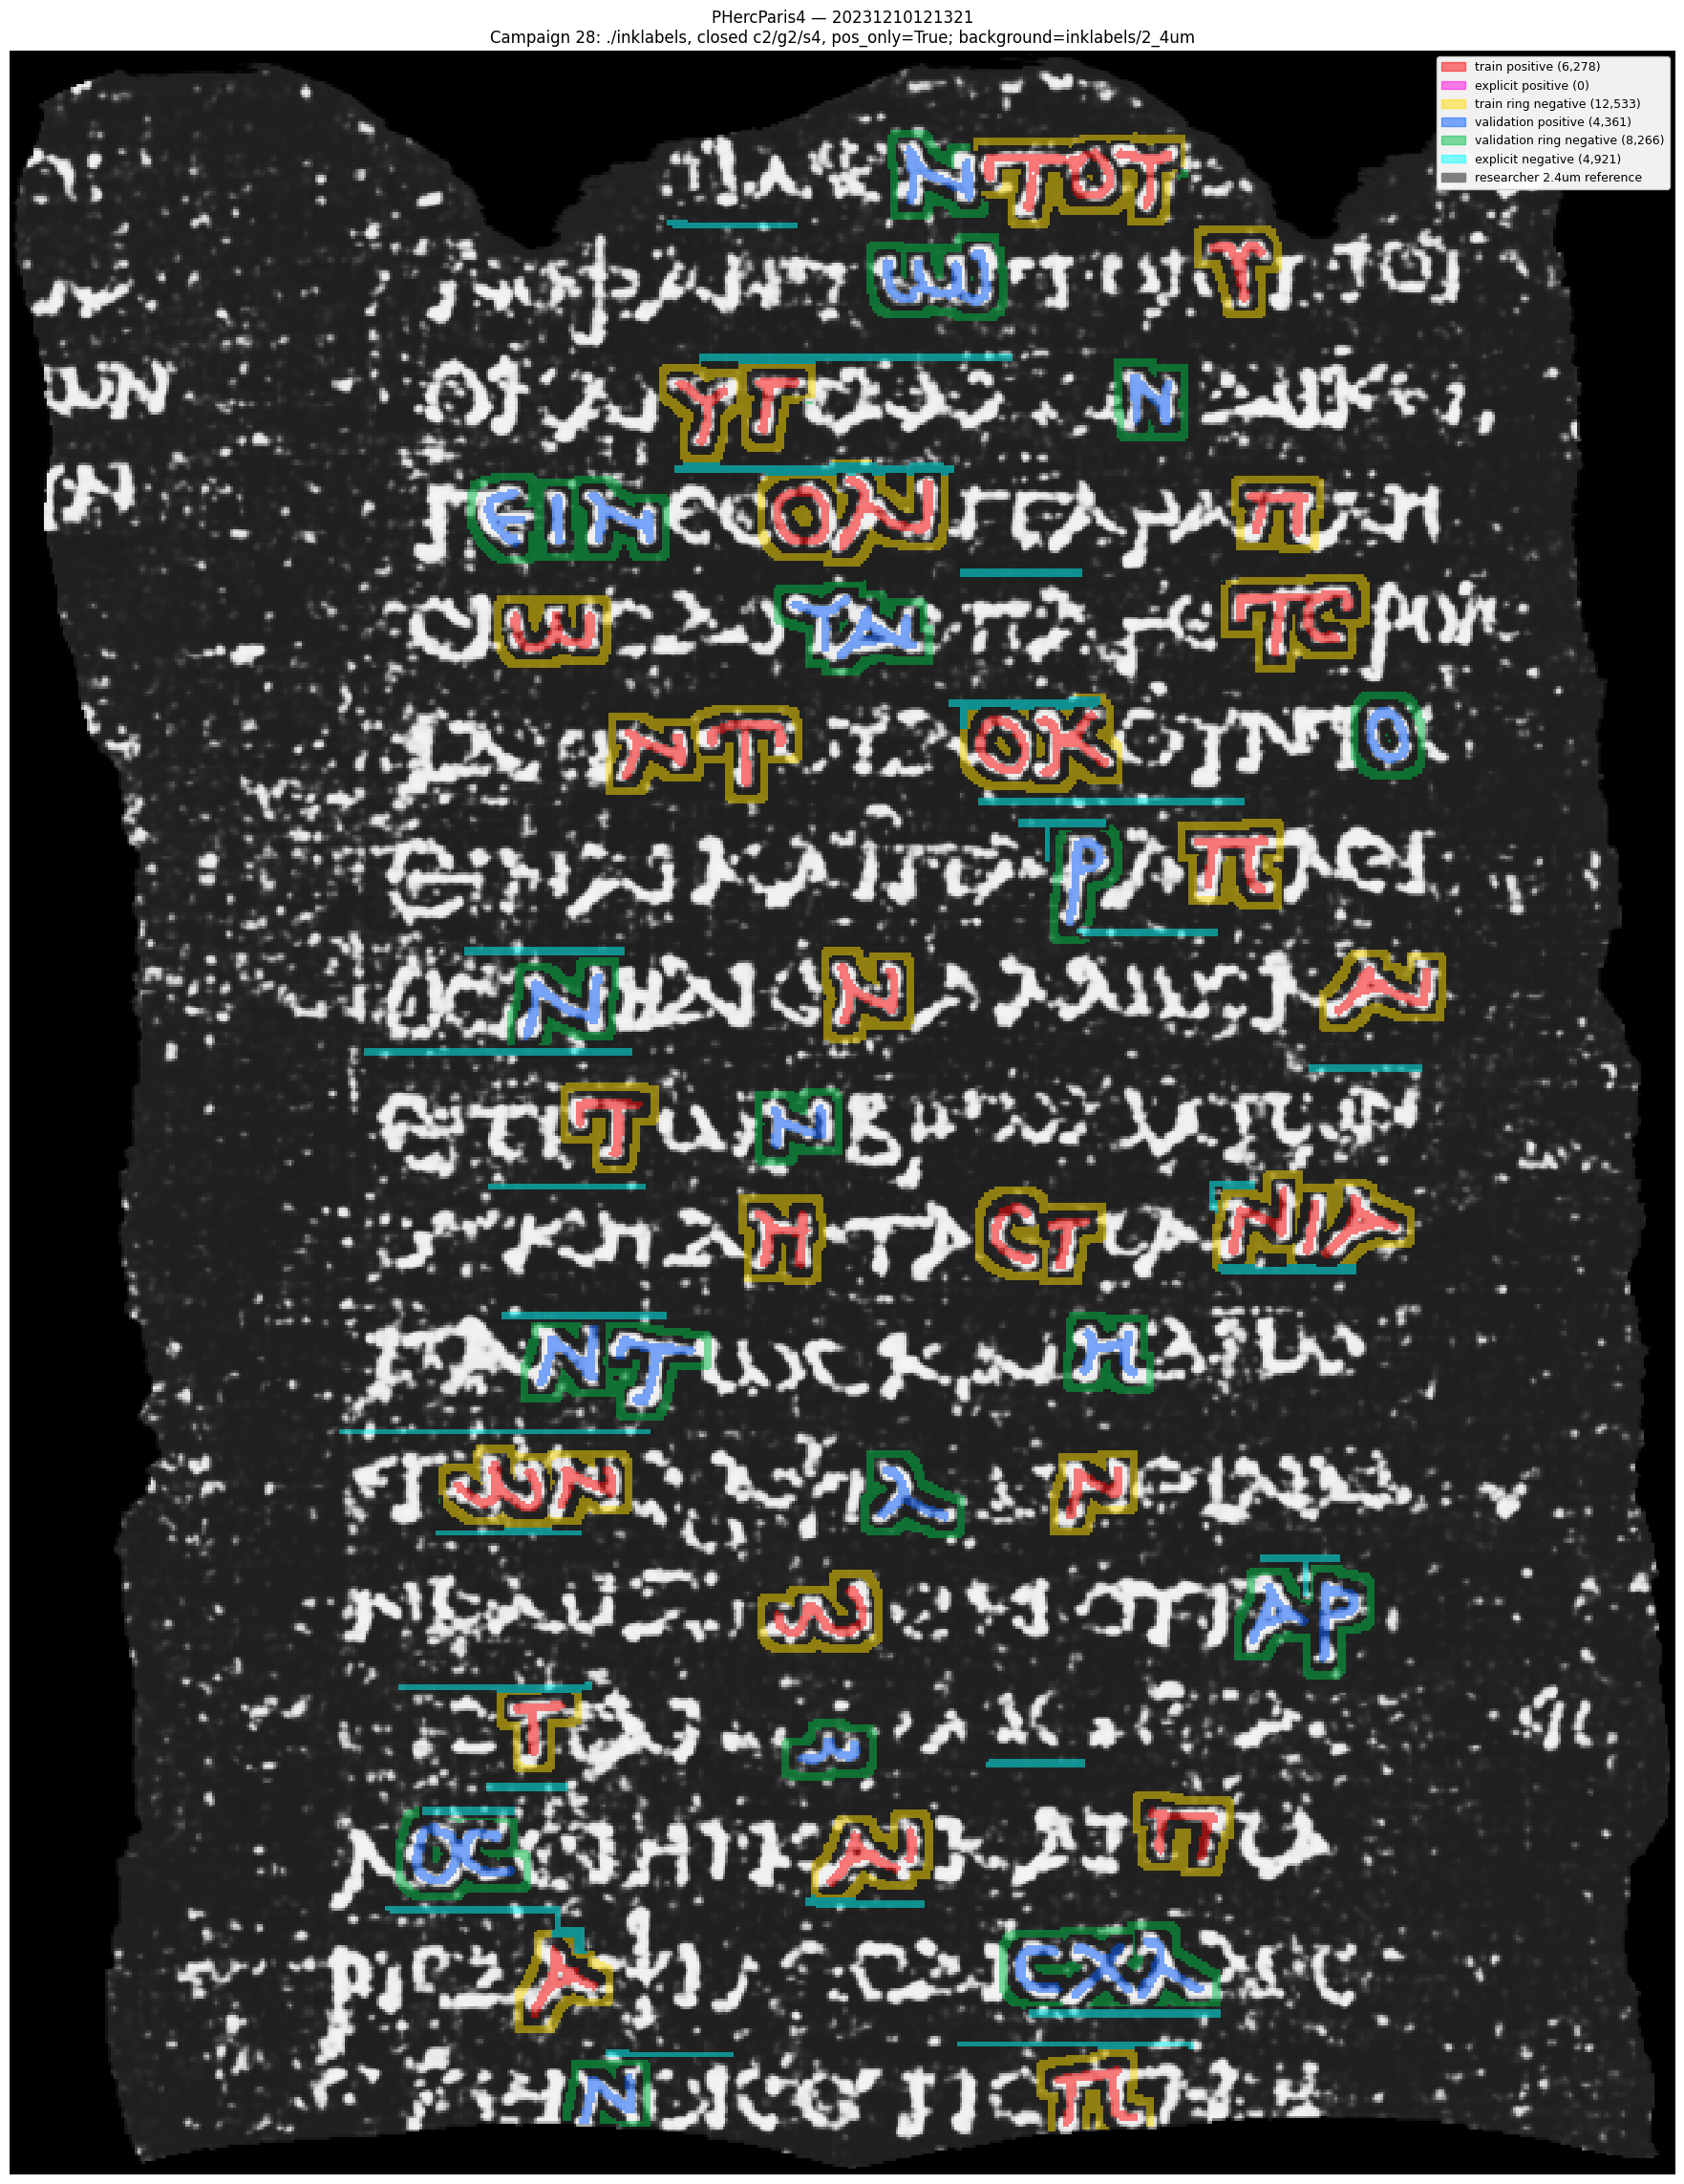

{'train_positive': 6278,
 'explicit_positive': 0,
 'train_negative': 12533,
 'valid_positive': 4361,
 'valid_negative': 8266,
 'explicit_negative': 4921}

In [11]:
render_scroll(20231210121321, SCROLL_NAMES[20231210121321])

[split] scroll 20250628074500: manual mask=./train_masks/20250628074500.png train_pixels=11.8% explicit_negative_pixels=862,976 explicit_positive_pixels=0
[split] scroll 20250628074500: axis=x train_frac=0.6
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=7026
[ring_negatives] source='closed' tile_radius=4  ink_tiles=3386  ring_tiles=6585  ratio=1.94
[manual-split] scroll 20250628074500: unit=16px train_ring=1530112px valid_ring=1022464px
[context-replace] scroll 20250628074500: 2785 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20250628074500_campaign28_split.png
unique targets {'train_positive': 1694, 'explicit_positive': 0, 'train_negative': 1390, 'valid_positive': 830, 'valid_negative': 1843, 'explicit_negative': 2713}
train occurrences {'windows': 11914, 'positive_occurrences': 27104, 'negative_occurrences': 22240, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 43408}
valid occurrences {'windows': 6400, 'po

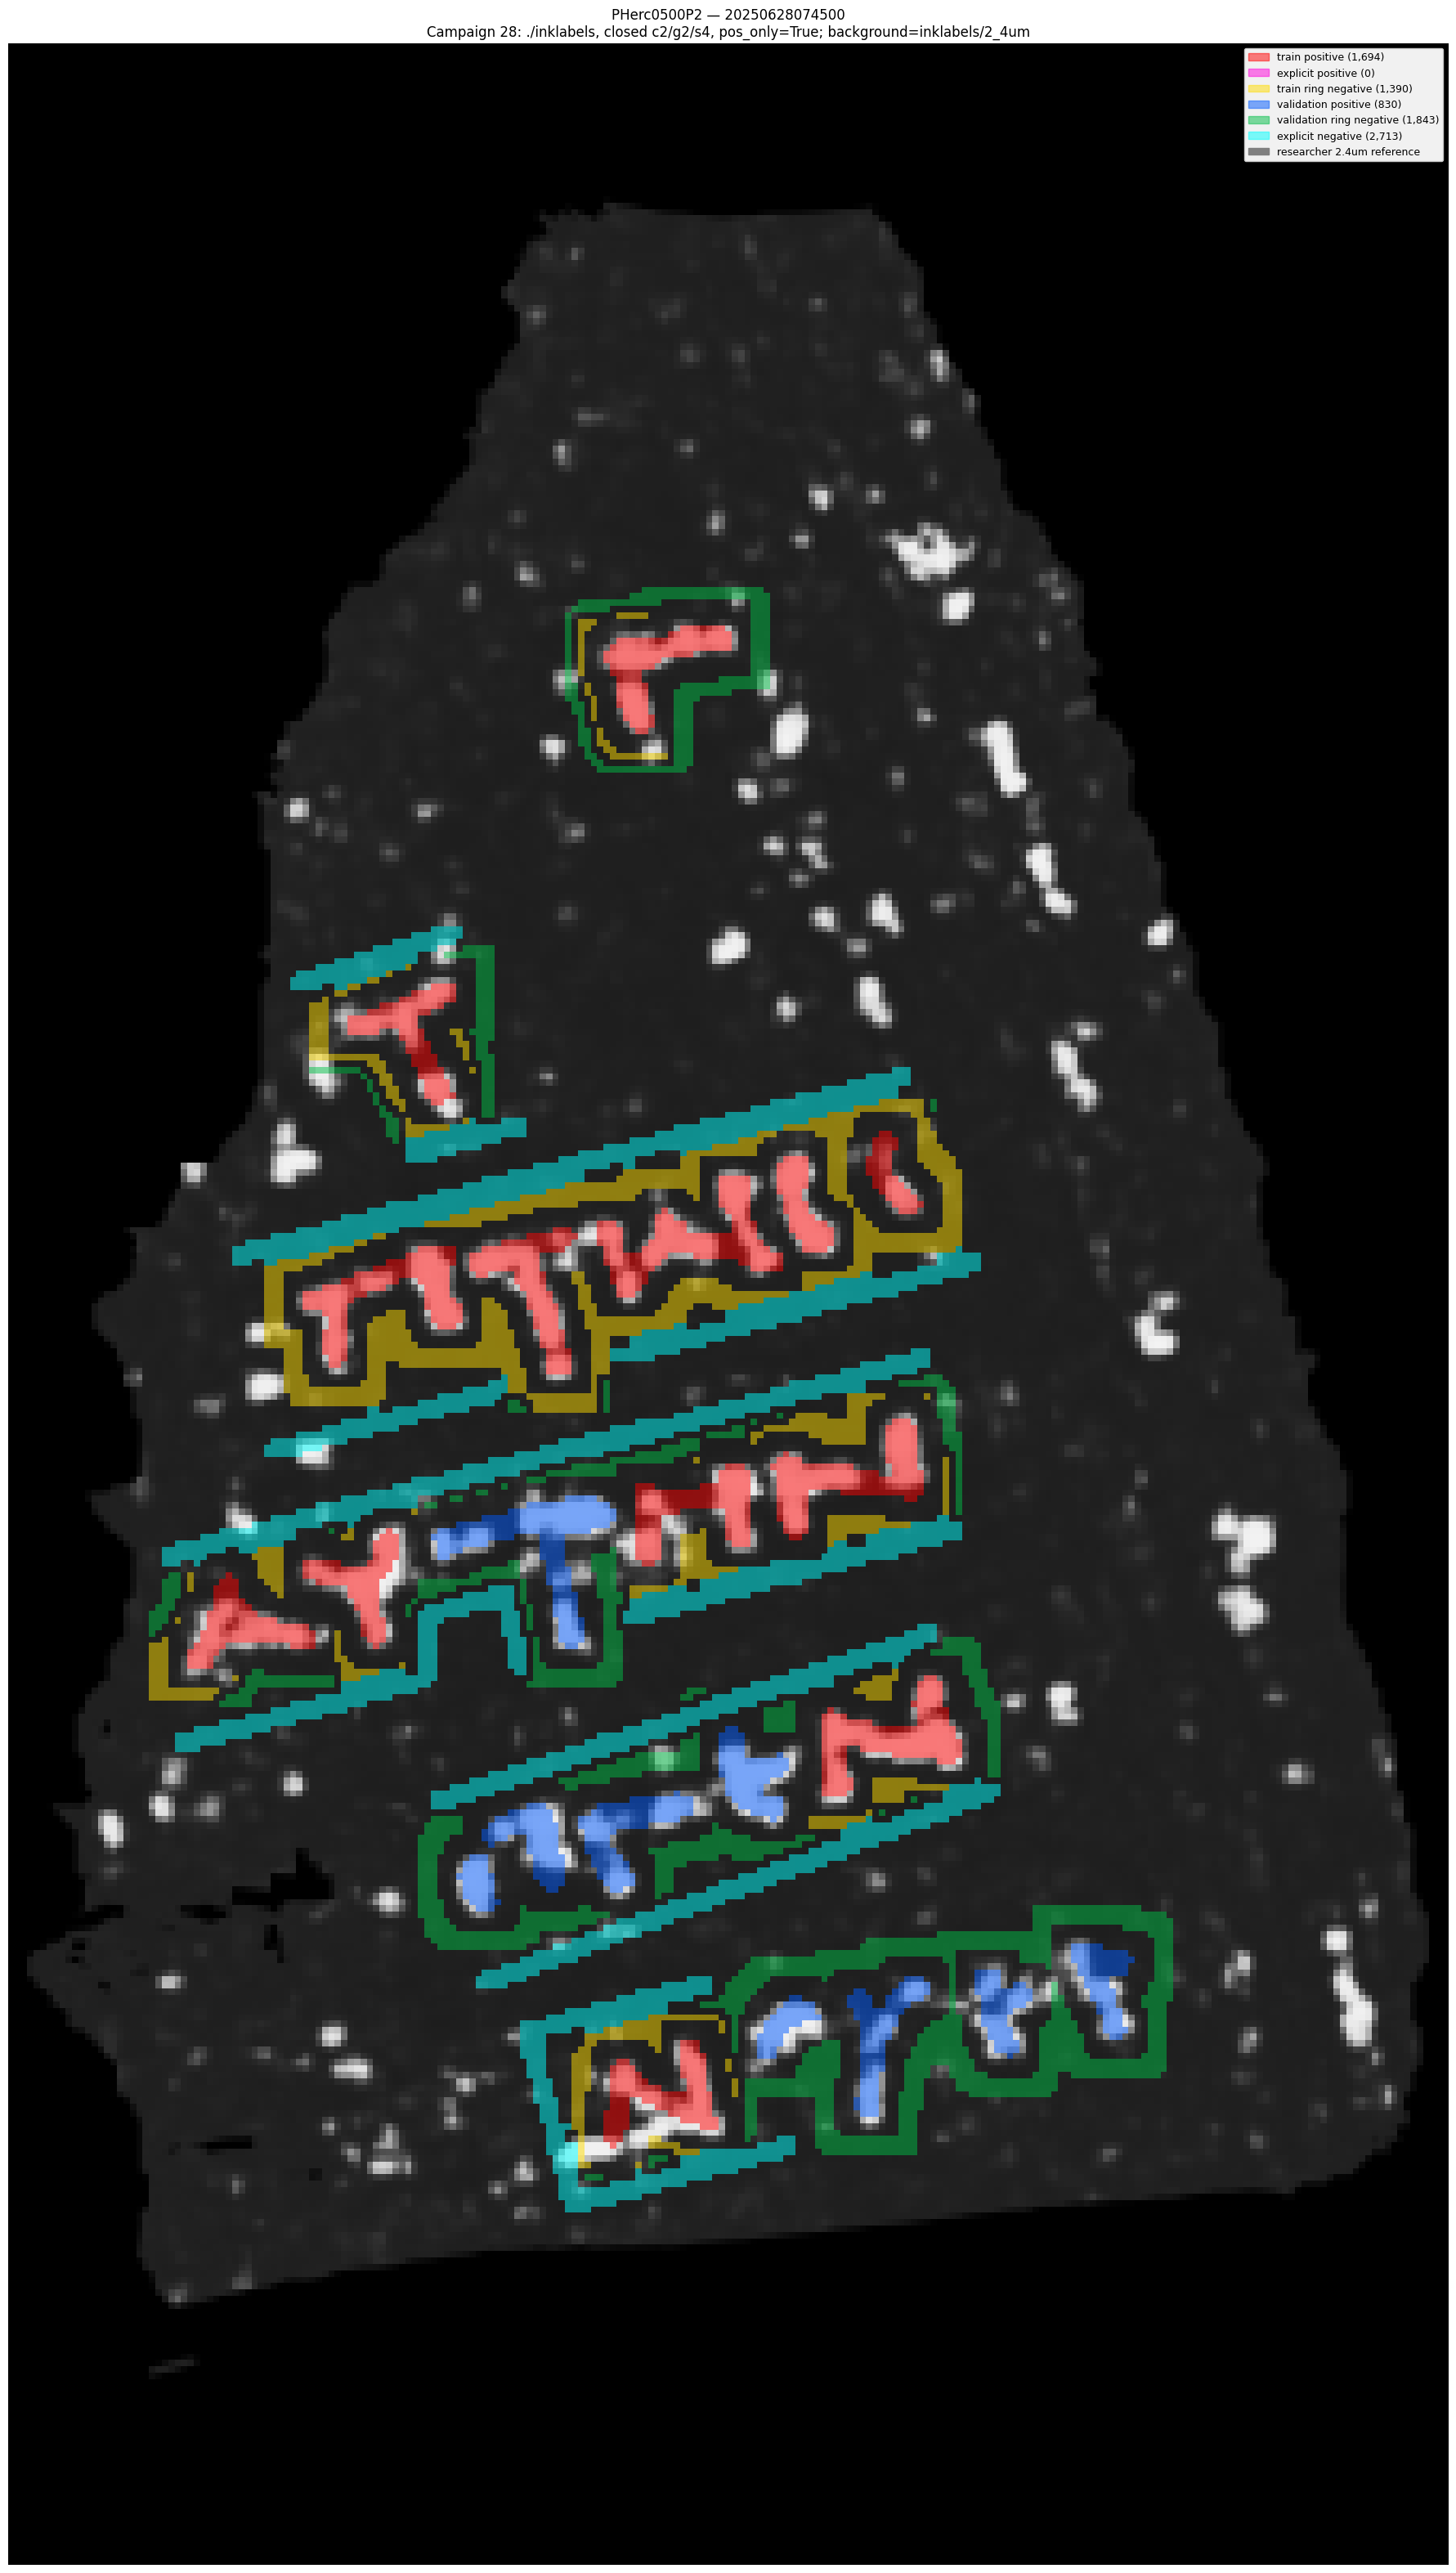

{'train_positive': 1694,
 'explicit_positive': 0,
 'train_negative': 1390,
 'valid_positive': 830,
 'valid_negative': 1843,
 'explicit_negative': 2713}

In [12]:
render_scroll(20250628074500, SCROLL_NAMES[20250628074500])

[explicit-negative] scroll 20260226000000: overriding 92 ink-label pixels
[split] scroll 20260226000000: manual mask=./train_masks/20260226000000.png train_pixels=8.9% explicit_negative_pixels=188,284 explicit_positive_pixels=0
[split] scroll 20260226000000: axis=y train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=1961
[ring_negatives] source='closed' tile_radius=4  ink_tiles=929  ring_tiles=1730  ratio=1.86
[manual-split] scroll 20260226000000: unit=16px train_ring=436224px valid_ring=244480px
[context-replace] scroll 20260226000000: 346 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20260226000000_campaign28_split.png
unique targets {'train_positive': 407, 'explicit_positive': 0, 'train_negative': 295, 'valid_positive': 250, 'valid_negative': 338, 'explicit_negative': 647}
train occurrences {'windows': 2933, 'positive_occurrences': 6512, 'negative_occurrences': 4720, 'explicit_positive_occurrences': 0, 'explicit_negati

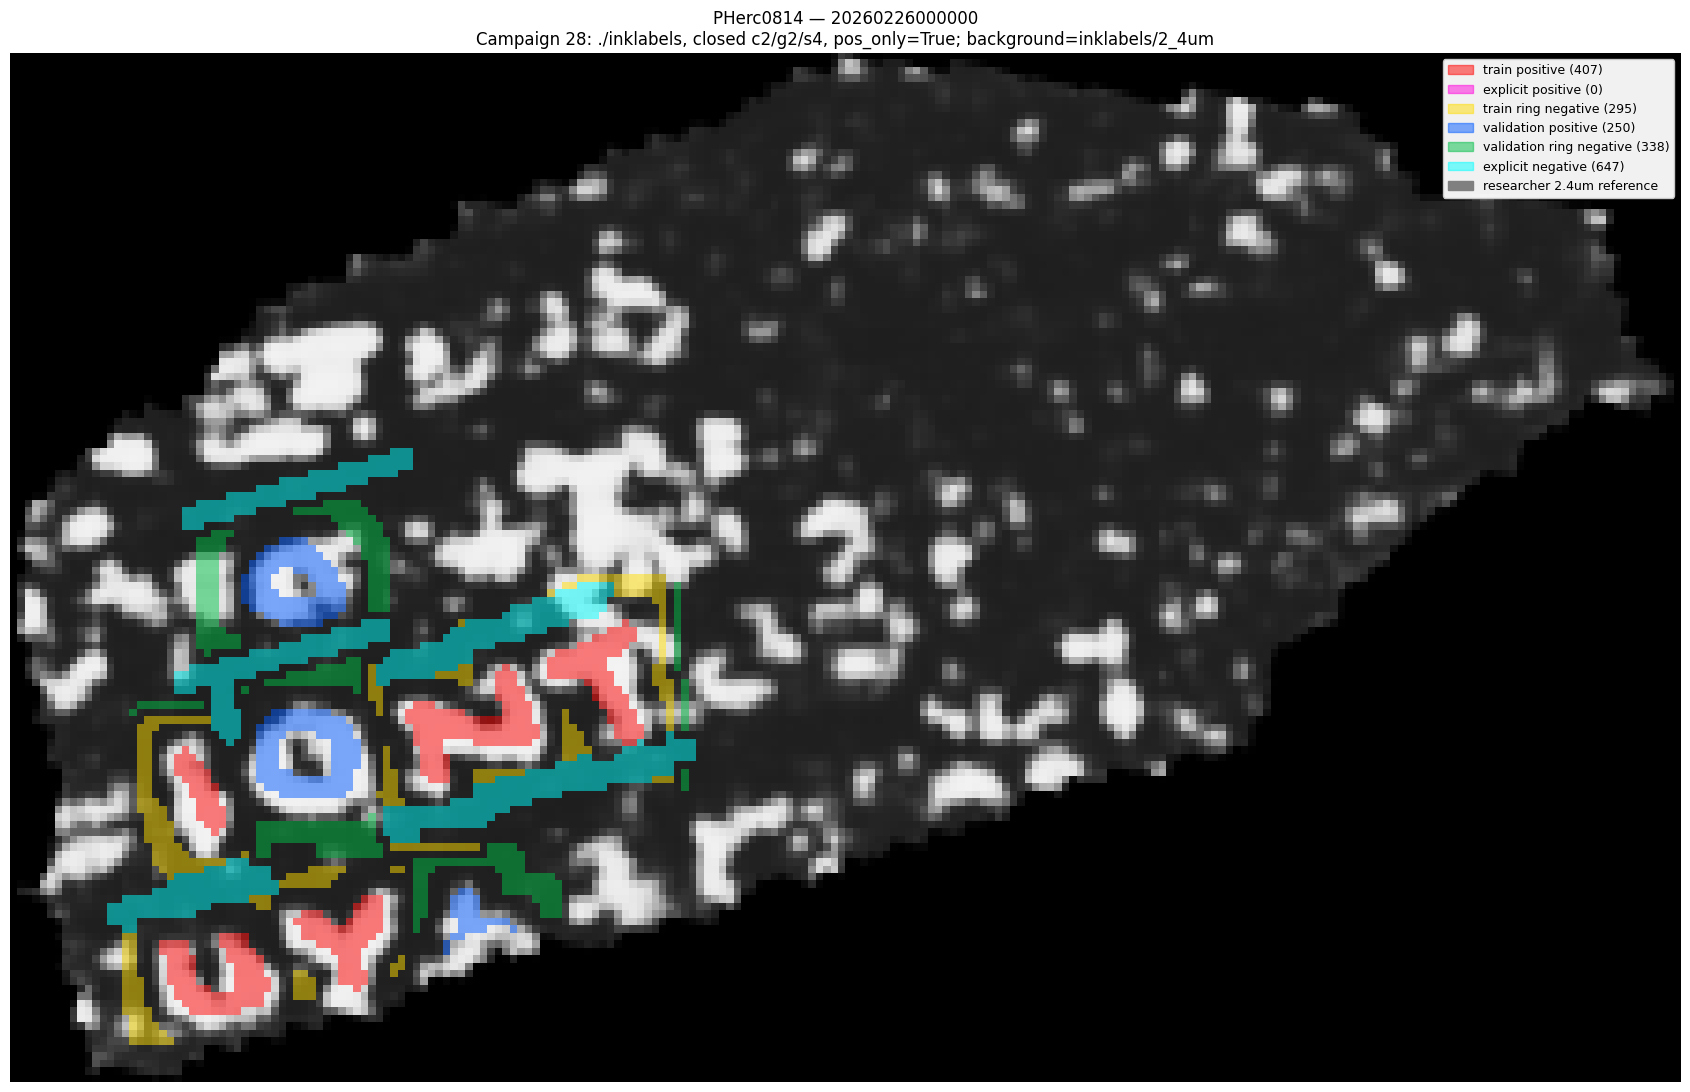

{'train_positive': 407,
 'explicit_positive': 0,
 'train_negative': 295,
 'valid_positive': 250,
 'valid_negative': 338,
 'explicit_negative': 647}

In [13]:
render_scroll(20260226000000, SCROLL_NAMES[20260226000000])

[split] scroll 20230301213755: manual mask=./train_masks/20230301213755.png train_pixels=51.4% explicit_negative_pixels=0 explicit_positive_pixels=0
[split] scroll 20230301213755: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=20962
[ring_negatives] source='closed' tile_radius=4  ink_tiles=9549  ring_tiles=16962  ratio=1.78
[manual-split] scroll 20230301213755: unit=16px train_ring=5897984px valid_ring=888832px
[context-replace] scroll 20230301213755: 2204 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20230301213755_campaign28_split.png
unique targets {'train_positive': 5866, 'explicit_positive': 0, 'train_negative': 11044, 'valid_positive': 980, 'valid_negative': 1142, 'explicit_negative': 0}
train occurrences {'windows': 34226, 'positive_occurrences': 93856, 'negative_occurrences': 176704, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 0}
valid occurrences {'windows': 5276, 'positive_oc

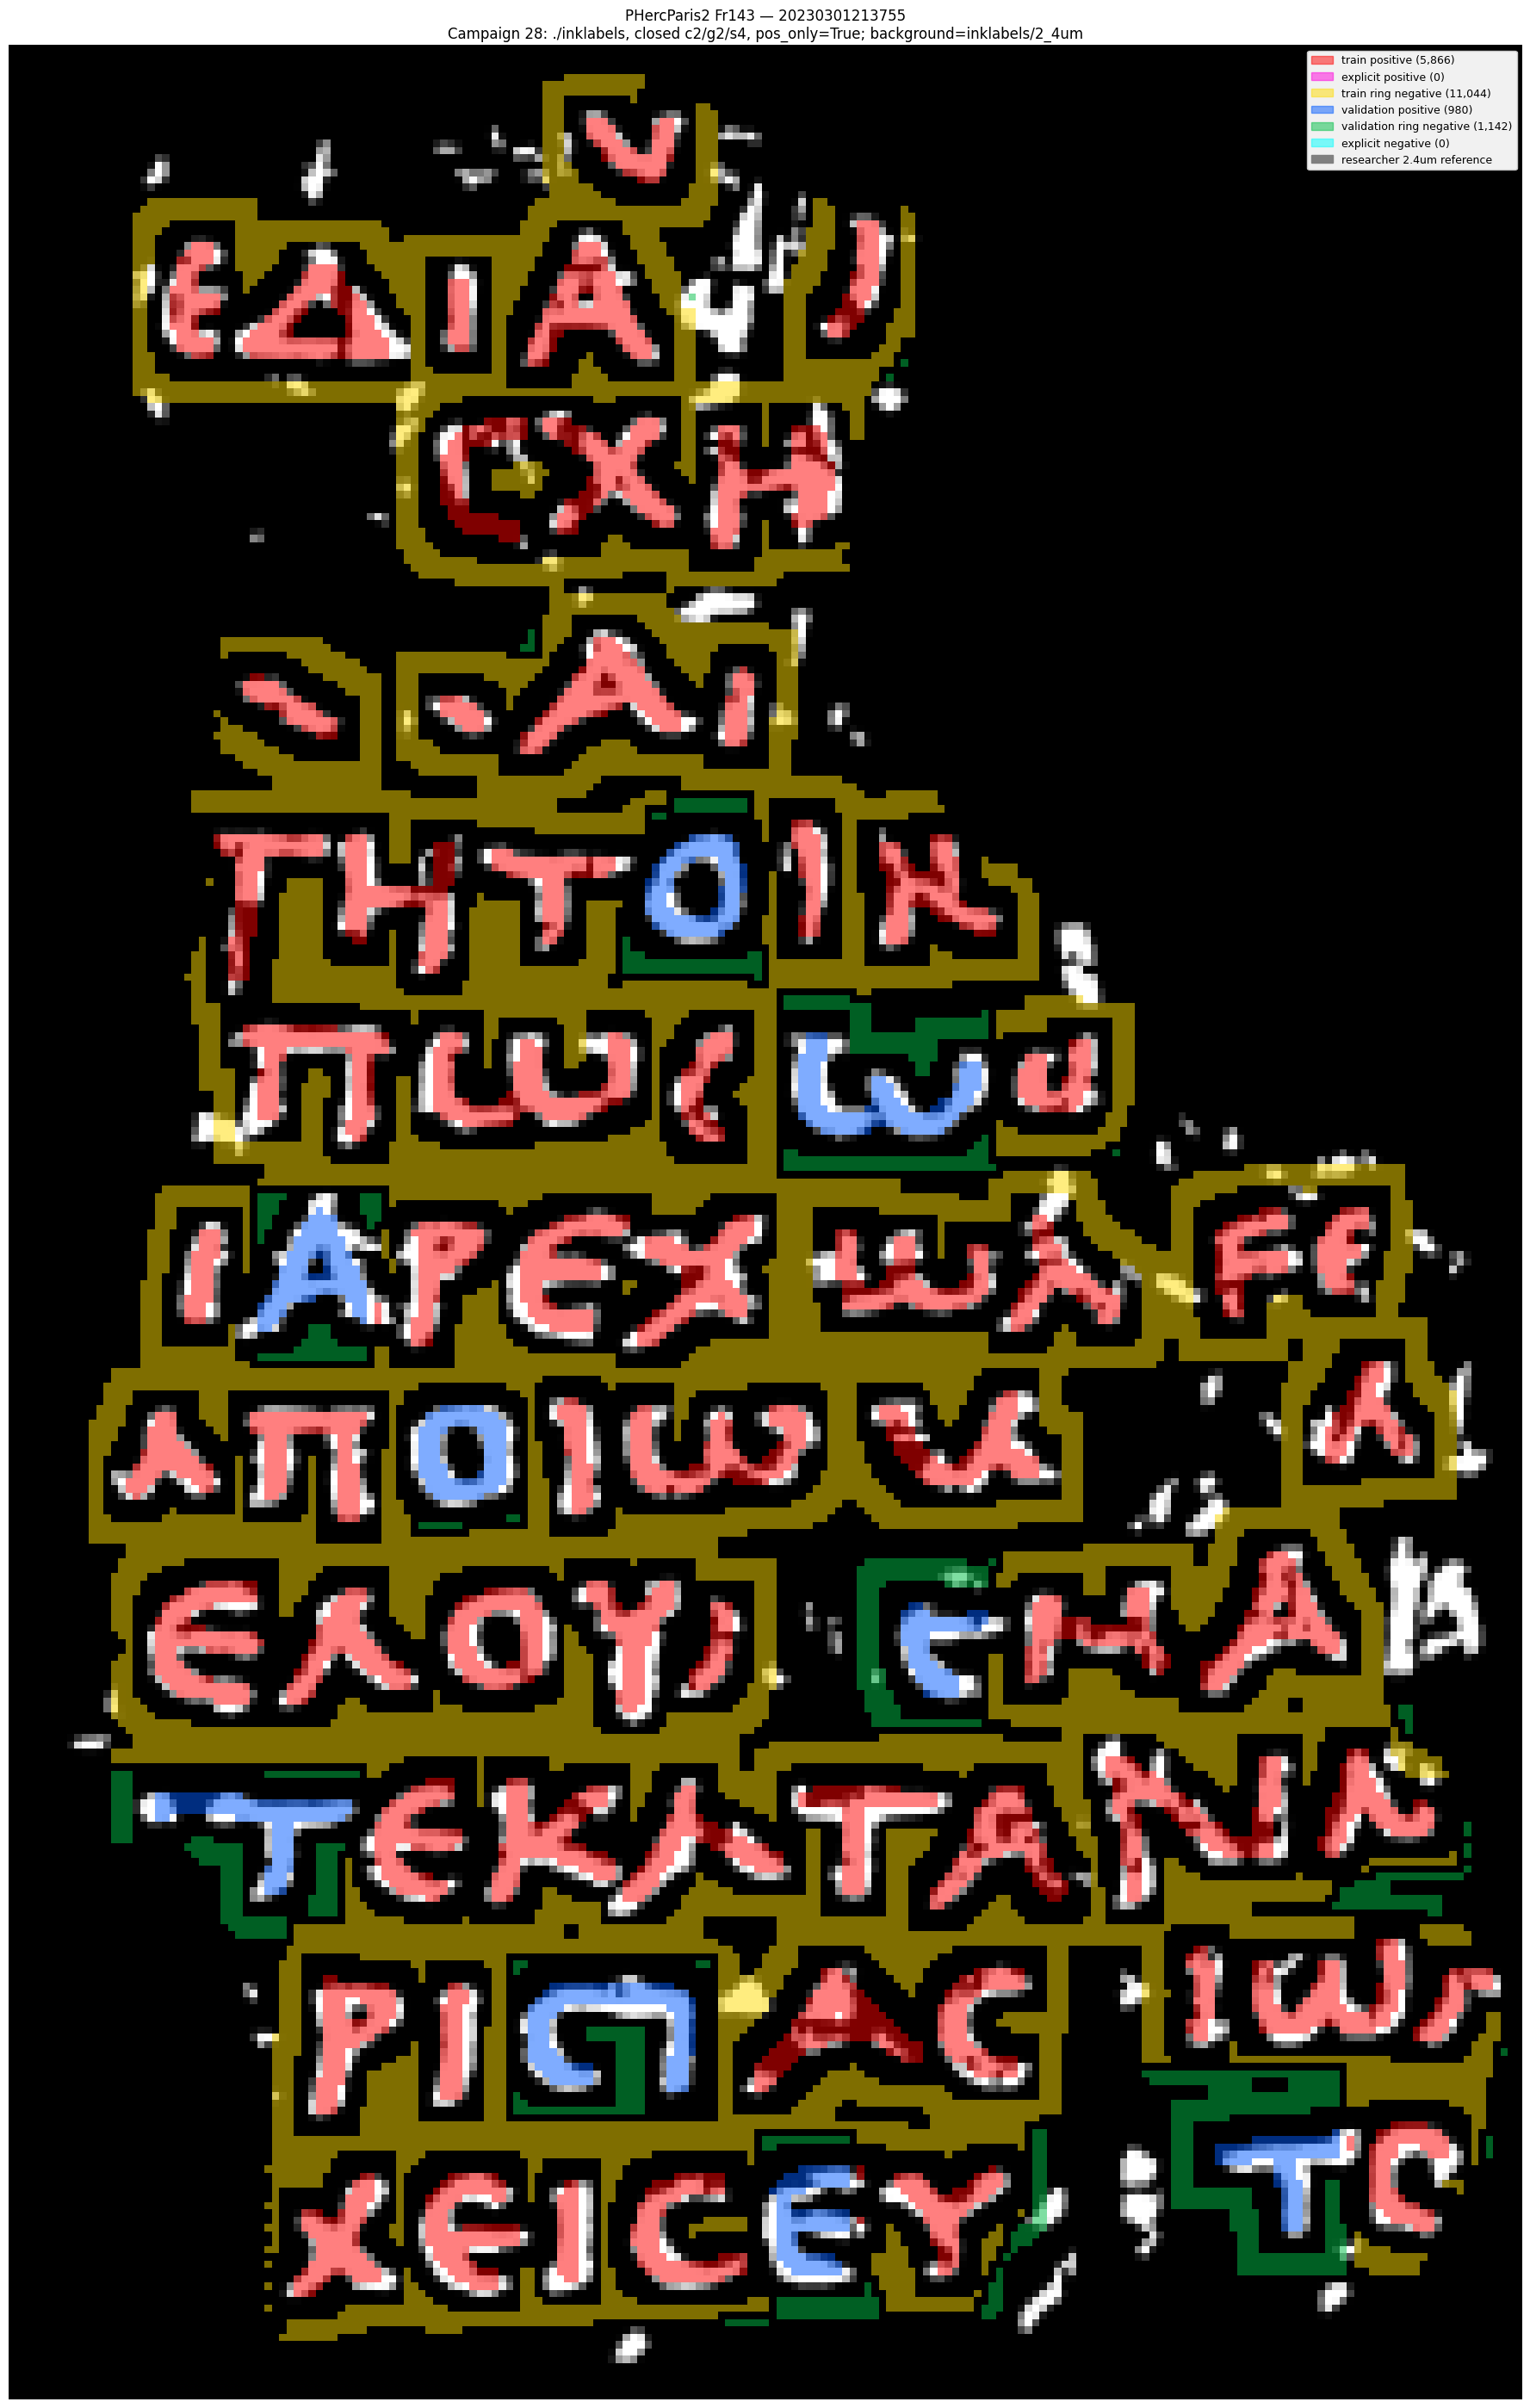

{'train_positive': 5866,
 'explicit_positive': 0,
 'train_negative': 11044,
 'valid_positive': 980,
 'valid_negative': 1142,
 'explicit_negative': 0}

In [14]:
render_scroll(20230301213755, SCROLL_NAMES[20230301213755])

[split] scroll 20231205222200: manual mask=./train_masks/20231205222200.png train_pixels=37.8% explicit_negative_pixels=0 explicit_positive_pixels=0
[split] scroll 20231205222200: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=5901
[ring_negatives] source='closed' tile_radius=4  ink_tiles=2606  ring_tiles=5746  ratio=2.20
[manual-split] scroll 20231205222200: unit=16px train_ring=1664512px valid_ring=473600px
[context-replace] scroll 20231205222200: 897 fully ink-free donors with mask>=0.80
saved /vesuvius/output/campaign28_split_audit/20231205222200_campaign28_split.png
unique targets {'train_positive': 1452, 'explicit_positive': 0, 'train_negative': 3183, 'valid_positive': 385, 'valid_negative': 742, 'explicit_negative': 0}
train occurrences {'windows': 9926, 'positive_occurrences': 23232, 'negative_occurrences': 50928, 'explicit_positive_occurrences': 0, 'explicit_negative_occurrences': 0}
valid occurrences {'windows': 2802, 'positive_occurrenc

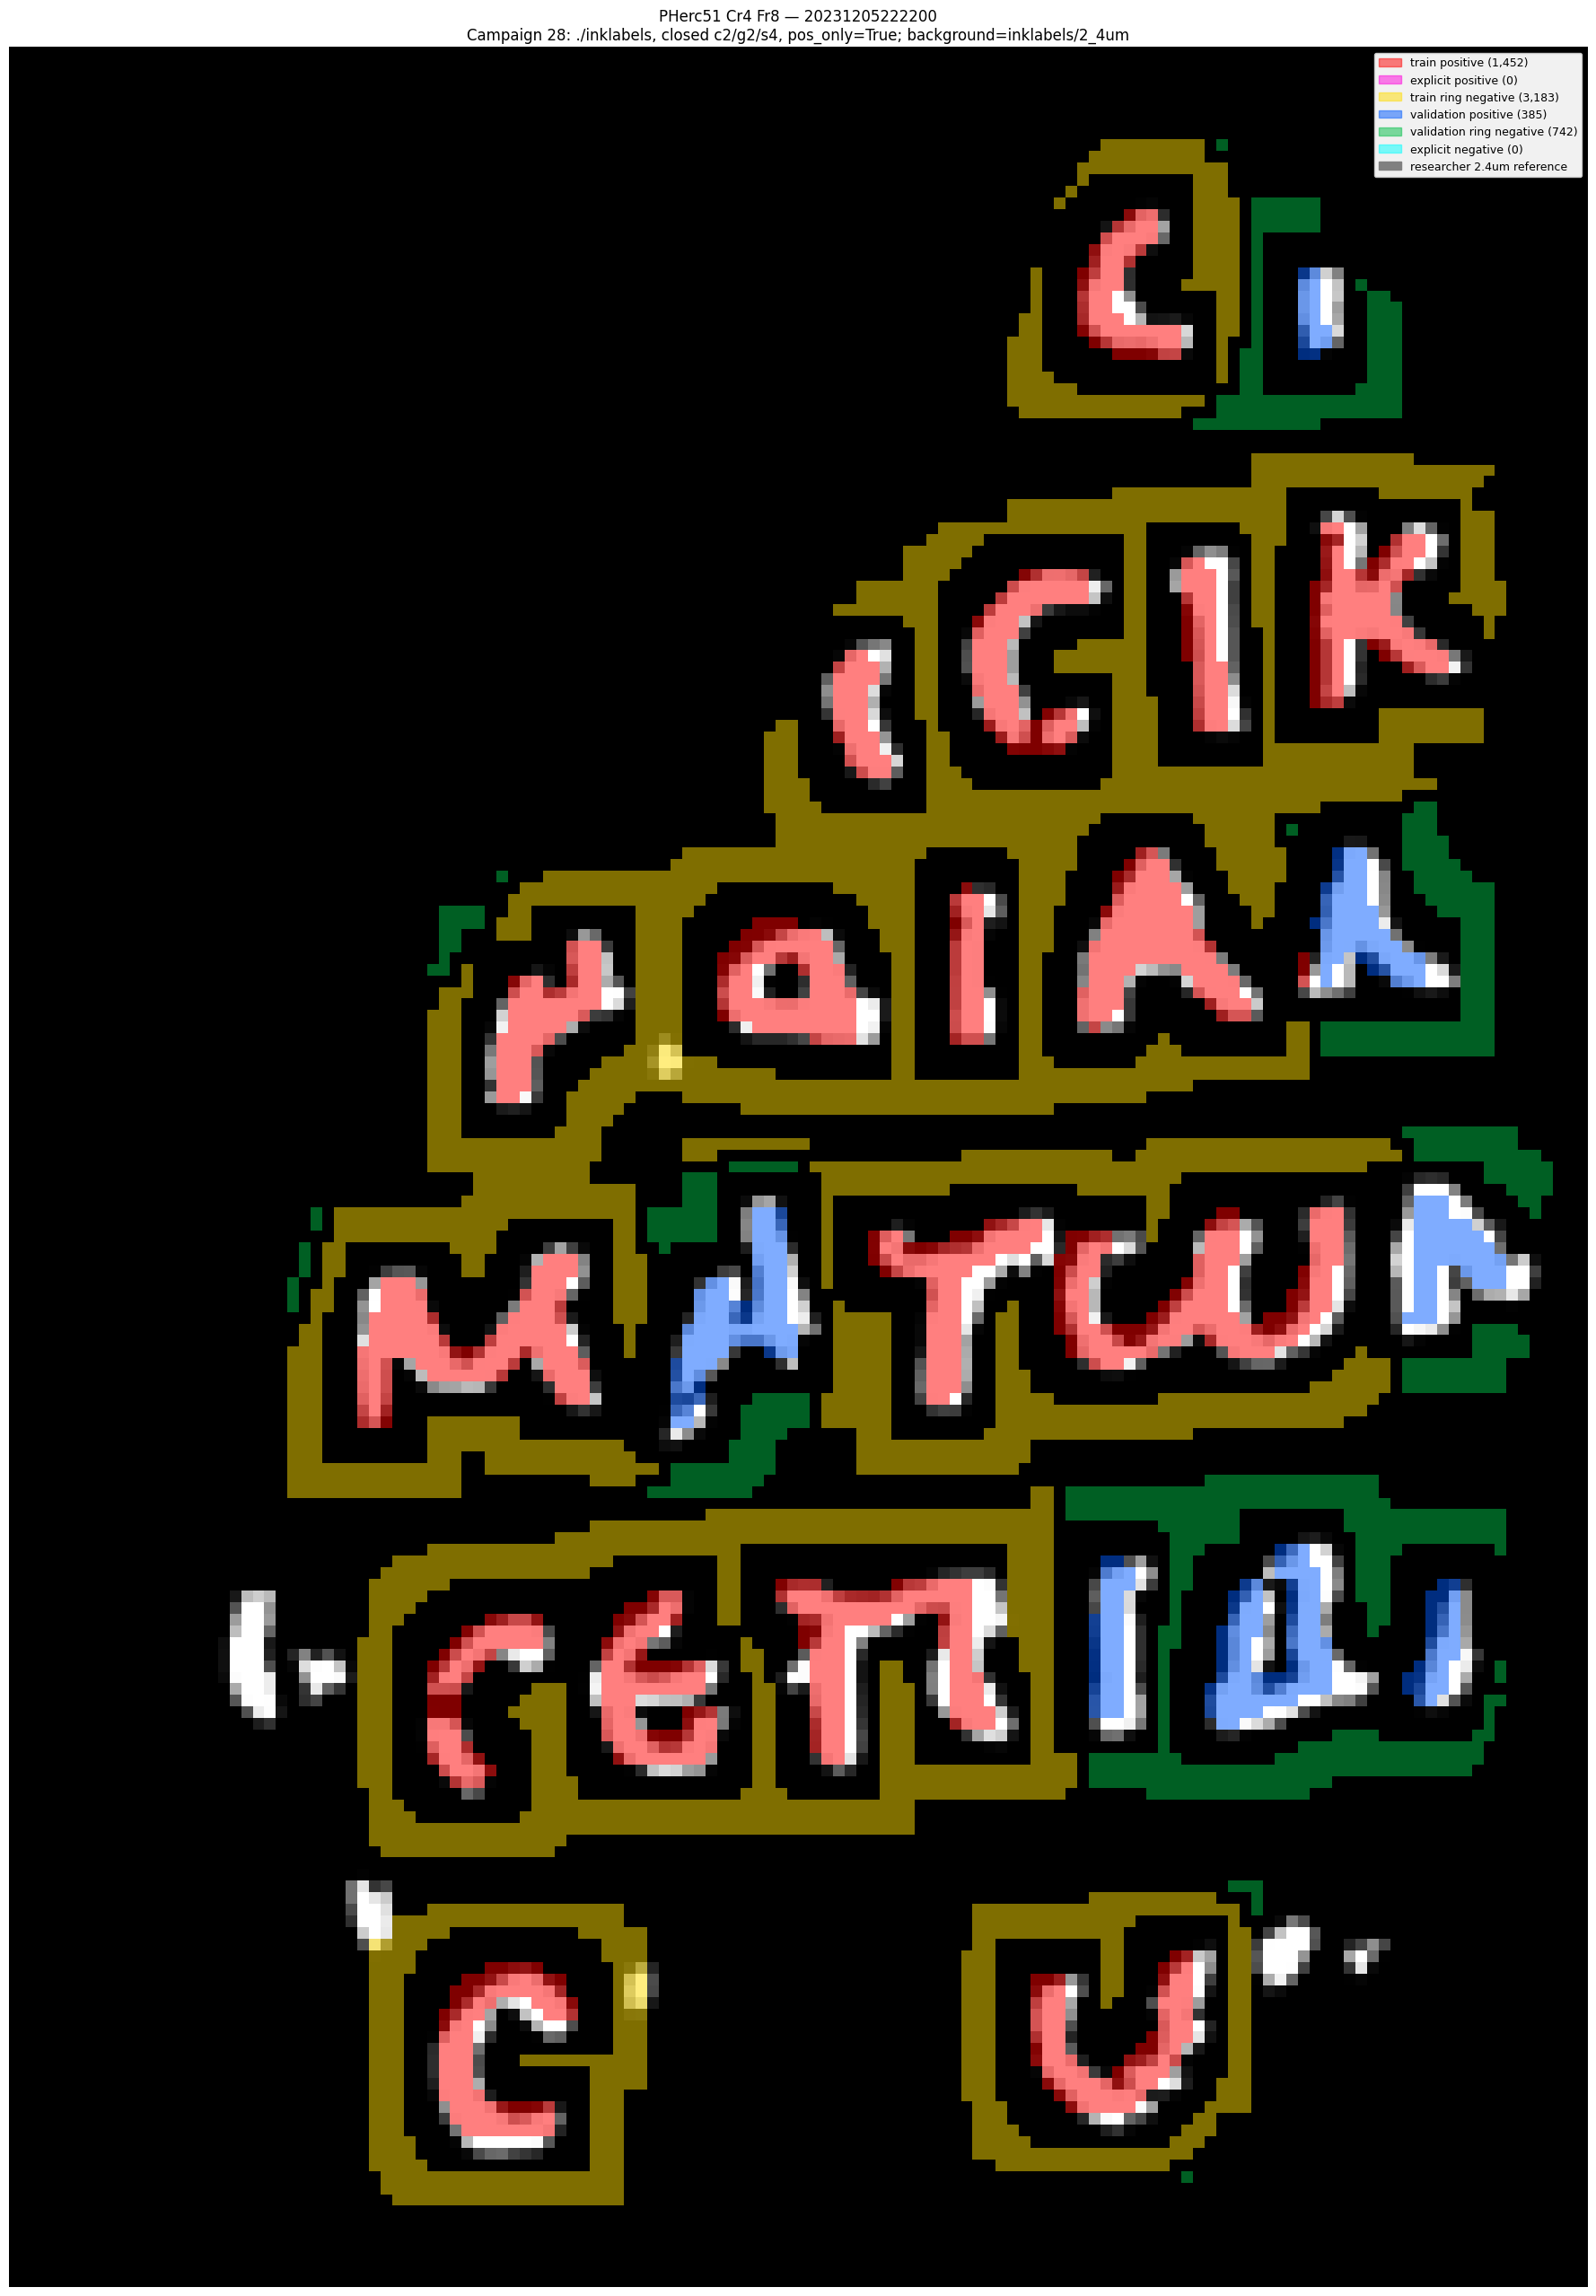

{'train_positive': 1452,
 'explicit_positive': 0,
 'train_negative': 3183,
 'valid_positive': 385,
 'valid_negative': 742,
 'explicit_negative': 0}

In [15]:
render_scroll(20231205222200, SCROLL_NAMES[20231205222200])

In [21]:
render_scroll(20230301213423, SCROLL_NAMES[20230301213423])

[split] scroll 20230301213423: manual mask=./train_masks/20230301213423.png train_pixels=21.7% explicit_negative_pixels=0 explicit_positive_pixels=0
[split] scroll 20230301213423: axis=x train_frac=0.75
[ring] closed(base=regular): CLOSE_R=2 GAP_R=2 exclusion_tiles=3670
[ring_negatives] source='closed' tile_radius=4  ink_tiles=1509  ring_tiles=3126  ratio=2.07
[manual-split] scroll 20230301213423: unit=16px train_ring=671744px valid_ring=514816px
[context-replace] scroll 20230301213423: 66 fully ink-free donors with mask>=0.80


[ WARN:0@3551.947] global loadsave.cpp:268 findDecoder imread_('/vesuvius/inklabels/2_4um/20230301213423.png'): can't open/read file: check file path/integrity


FileNotFoundError: researcher 2.4um reference missing: /vesuvius/inklabels/2_4um/20230301213423.png